In [1]:
import numpy as np
import healpy as hp

import matplotlib
from matplotlib import pyplot as plt

from scipy import stats
import matplotlib.gridspec as gridspec
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
from matplotlib import cm
from scipy.optimize import minimize
from astropy.cosmology import Planck18
from dynesty import NestedSampler
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
from astropy.coordinates import SkyCoord
from healpy.newvisufunc import projview

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using step-function HOD
## Define parameters

In [165]:
G_hi = 20.5

In [4]:
nthreads = 18

In [5]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.6])
z_array = range(len(z_bins)-1)
mask = 0.5

In [6]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

In [7]:
Delta = 200
delta_c = 1.686

In [8]:
hmf = ccl.halos.MassFuncTinker10()

In [9]:
NSIDE = 64

In [10]:
M_max = 15

## Define functions

In [11]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [12]:
def b_qso(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

In [13]:
def nu(M, delta_c = delta_c, a = 1, cosmo = cosmo_planck18):
    
    sigma = cosmo.sigmaM(M, a = a)
   
    return delta_c/sigma

In [14]:
def n_g_theory(bins, n_total, a = 1, cosmo = cosmo_planck18, hmf = hmf, recenter = True):

    if recenter == True:
        bins = quaia.recenter(bins)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3
    n_g = nm/(bins*np.log(10))*n_total
    n_g[np.isnan(n_g)]=0
    
    return n_g, nm

def bias(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter)
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
    n_g = np.trapz(n_g, bins)
    dn_dm = nm/(bins*np.log(10))

    b1_E_tinker = b1_E_func(nu(bins, a = a, cosmo = cosmo), mod = mod)

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    return bias_function(n_g, integrand, b1_E_tinker, bins, recenter = recenter), n_g

In [15]:
def b1_E_func(nu, Delta = Delta, delta_c = delta_c, mod = False):

    delta_c = 1.686
    
    if mod == False:
        y = np.log10(Delta)
        A =  1.0+0.24*y*np.exp(-(4/y)**4)
        a = 0.44*y-0.88
        B = 0.183
        b =  1.5
        C = 0.019+0.107*y+0.19*np.exp(-(4/y)**4)
        c = 2.4
        
    else:
        A =  1.0
        a = 0.0906
        B = -4.5002
        b =  2.1419
        C = 4.9148
        c = 2.1419
        
    return 1-A*nu**a/(nu**a+delta_c**a)+B*nu**b+C*nu**c # Jose et al
    
def bias_function(n_g, integrand, b, bins, recenter = True):
    
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
        
    return 1/n_g*np.trapz(integrand*b, bins)

In [16]:
def cf_2h(bins, n_m, a, cosmo, cf_matter, recenter = True):
    
    b_q, n_g = bias(bins, n_m, a, cosmo, recenter = recenter)
    return b_q**2*cf_matter, b_q

In [17]:
def M(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True, hmf = hmf):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter, hmf = hmf)
    if recenter == True:
        n_g = np.trapz(n_g, quaia.recenter(bins))
        dm = np.diff(bins) 
        dn_dm = nm/(quaia.recenter(bins)*np.log(10))
    else:
        n_g = np.trapz(n_g, bins)
        dn_dm = nm/(bins*np.log(10))

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    if recenter == True:
        return bias_function(n_g, integrand, quaia.recenter(bins), bins, recenter = recenter), n_g
    else:
        return bias_function(n_g, integrand, bins, bins, recenter = recenter), n_g

In [18]:
def HOD(bins, M_min, fduty):

    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=M_min]=fduty

    return n_m

In [19]:
def n_DM(cosmo, a, M_min, hmf = hmf, M_max = M_max, N = 79): #16.8
    
    bins = np.logspace(M_min, M_max, N)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 #/u.Mpc**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.trapz(dn_dm, bins)

# Implement halo model
## Plot HOD: $\langle N(M) \rangle = \begin{cases}f_{duty} & M\geq M_{min} \\ 0 & M<M_{min}\end{cases}$
### At fixed $f_{duty}$ and $M_{min}$

In [103]:
bins = np.logspace(9, M_max, 79)
# M_min = 12.8

In [104]:
# M_min_array = [12.86, 12.74, 12.79, 12.82]
M_min_array = [11.94, 11.98, 11.97, 12.07]

In [105]:
# fduty = [0.018, 0.022, 0.056, 0.071]
fduty = [0.002, 0.002, 0.003, 0.002]
n_m_array = []
for i in z_array:        
    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=10**M_min_array[i]]=fduty[i]
    n_m_array.append(n_m)

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_250170/3618045427.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))
/tmp/ipykernel_250170/3618045427.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M (M_\odot)$')


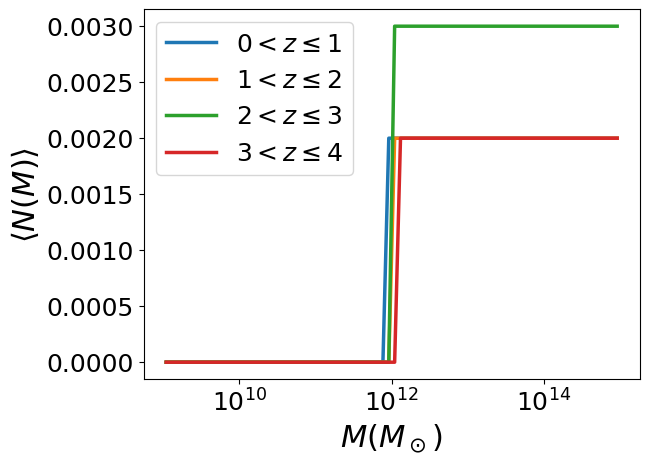

In [106]:
for i in z_array:
        
    plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))

plt.xscale('log')
plt.xlabel('$M (M_\odot)$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.show()

In [107]:
n_m_array, bins_M_min = [], []
for i in z_array:   
    bins_i = np.logspace(M_min_array[i], M_max, 79)
    n_m=np.ones(np.shape(bins_i))*fduty[i]
    n_m_array.append(n_m)
    bins_M_min.append(bins_i)

In [108]:
n_m_array_2D = []
for i in z_array:

    n_m_array_2D.append([])
    
    for j in range(len(bins)):
        
        n_m=np.ones(np.shape(bins))*fduty[i]
        n_m_array_2D[i].append(n_m)

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{qq}}(s)}{\xi^{(r)}_\mathrm{mm}(r)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$
### Use a 50th percentile mask

In [109]:
bins_M_min_array = [np.logspace(np.log10(bins[j]), M_max, 79) for j in range(len(bins))]

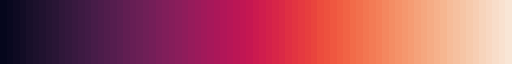

In [110]:
cmap = sns.color_palette("rocket", n_colors = len(bins))
palette = matplotlib.colors.ListedColormap(cmap)
palette

# Calculate derived parameters
## Plot b(z)

In [111]:
def b_eboss(z):
    
    return 0.278*((1+z)**2-6.565) + 2.393

def b_quaia(b_0, a, cosmo = cosmo_planck18): #quaia):
    
    return b_0/ccl.growth_factor(cosmo, a)

In [112]:
b_cf20 = np.load('../results/b_cf20_planck18.npy')
b_wp20 = np.load('../results/b_wp20_planck18.npy')

# Normalize the selection function

In [30]:
j = 2
tab_datahi_mask_zbin0, _, _, _, _, _, selfunc_hi_bin0, mask_datahi_bin0, _ = quaia.make_bins_raw(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


In [263]:
NPIX = hp.nside2npix(NSIDE)

In [264]:
fac_stdev = 0.7

In [265]:
name_catalog = '$Gaia$-$unWISE$ Quasar Catalog'

In [266]:
N_gcatlo_mask = len(tab_datahi_mask_zbin0)

In [267]:
cmap_map = 'plasma'
cbar_ticks = [5, 10, 20]

In [268]:
pixel_indices_datahi_bin0 = hp.ang2pix(NSIDE, tab_datahi_mask_zbin0['ra'], tab_datahi_mask_zbin0['dec'], lonlat=True)

0.9487440461546406 7.874009860095359


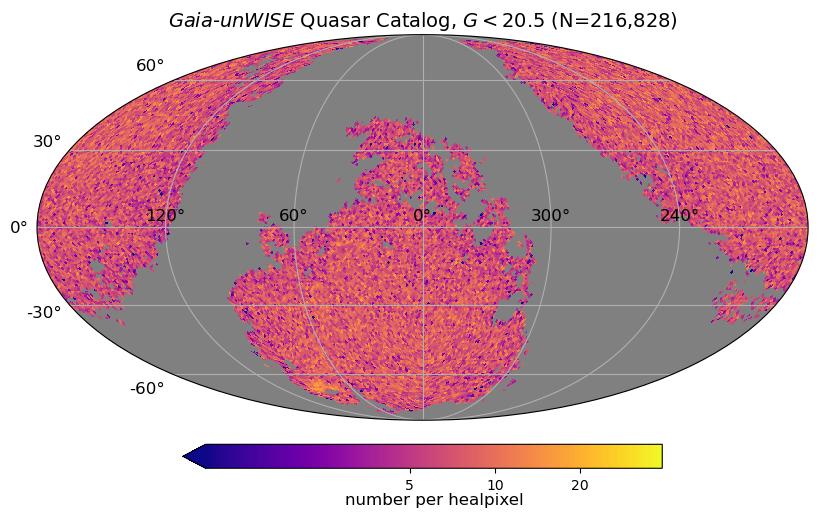

In [269]:
map_gcatlo = np.bincount(pixel_indices_datahi_bin0, minlength=NPIX)
print(np.mean(map_gcatlo)-fac_stdev*np.std(map_gcatlo), np.mean(map_gcatlo)+fac_stdev*np.std(map_gcatlo))
title_gcatlo = rf"{name_catalog}, $G<{G_hi}$ (N={N_gcatlo_mask:,})"
projview(map_gcatlo*hp.pixelfunc.nside2pixarea(NSIDE, degrees = True), title=title_gcatlo,
            unit=r"number per healpixel", cmap=cmap_map, coord=['C'], #, 'G']
            min=np.mean(map_gcatlo)-fac_stdev*np.std(map_gcatlo), max=np.mean(map_gcatlo)+10*fac_stdev*np.std(map_gcatlo), 
            norm='log', graticule=True, cbar_ticks=cbar_ticks, graticule_labels=True)

In [270]:
LMC = SkyCoord(['05 23 34.6 -69 45 22'], unit=(u.hourangle, u.deg)) #https://simbad.u-strasbg.fr/simbad/sim-id?Ident=Large+Magellanic+Cloud

In [271]:
LMC_radius = 9*u.deg

In [272]:
SMC = SkyCoord(['00 52 38.0 -72 48 01'], unit=(u.hourangle, u.deg)) # https://simbad.u-strasbg.fr/simbad/sim-id?Ident=small+Magellanic+Cloud

In [273]:
SMC_radius = 5*u.deg

In [274]:
c = SkyCoord(ra=tab_datahi_mask_zbin0['ra'].value*u.degree, dec=tab_datahi_mask_zbin0['dec'].value*u.degree)
LMC_idx, _, _, _ = SkyCoord.search_around_sky(LMC, c, LMC_radius)

In [275]:
SMC_idx, _, _, _ = SkyCoord.search_around_sky(SMC, c, SMC_radius)

In [276]:
MC_idx = np.append(LMC_idx,SMC_idx)

In [277]:
MC_mask = np.full_like(selfunc_hi_bin0, True, dtype = bool)
MC_mask[pixel_indices_datahi_bin0[MC_idx]] = False

In [278]:
selfunc_hi_bin0_norm = selfunc_hi_bin0/np.max(selfunc_hi_bin0[MC_mask])

In [279]:
selfunc_hi_bin0_norm_mask = selfunc_hi_bin0_norm[MC_mask]

In [280]:
np.max(selfunc_hi_bin0_norm[pixel_indices_datahi_bin0[MC_idx]])

1.6779283485697618

In [281]:
selfunc_hi_bin0_MC = np.copy(selfunc_hi_bin0_norm)
selfunc_hi_bin0_MC[pixel_indices_datahi_bin0[MC_idx]] = 0

In [282]:
selfunc_hi_bin0_MC[pixel_indices_datahi_bin0[MC_idx]]

array([0., 0., 0., ..., 0., 0., 0.])

0.020606507766140585 0.10528867452552607


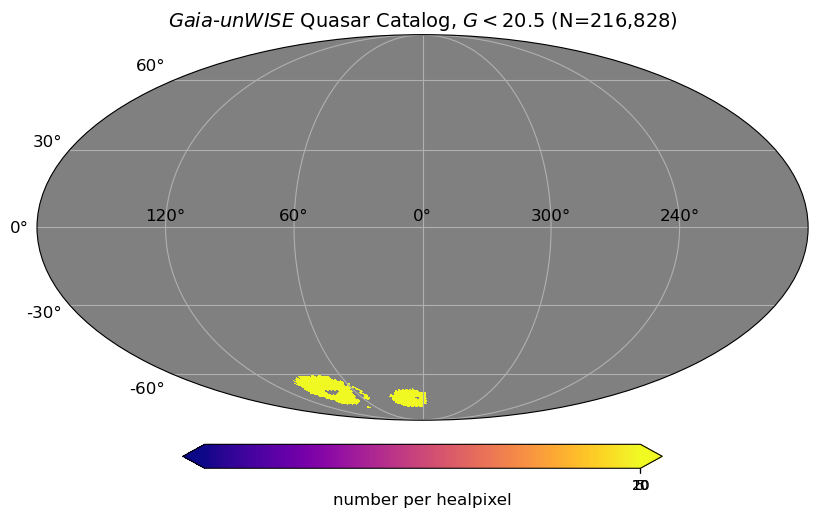

In [283]:
fac_stdev = 0.05
map_gcatlo = np.bincount(pixel_indices_datahi_bin0[MC_idx], minlength=NPIX)
print(np.mean(map_gcatlo)-fac_stdev*np.std(map_gcatlo), np.mean(map_gcatlo)+fac_stdev*np.std(map_gcatlo))
title_gcatlo = rf"{name_catalog}, $G<{G_hi}$ (N={N_gcatlo_mask:,})"
projview(map_gcatlo*hp.pixelfunc.nside2pixarea(NSIDE, degrees = True), title=title_gcatlo,
            unit=r"number per healpixel", cmap=cmap_map, coord=['C'], 
            min=np.mean(map_gcatlo)-fac_stdev*np.std(map_gcatlo), max=np.mean(map_gcatlo)+10*fac_stdev*np.std(map_gcatlo), 
            norm='log', graticule=True, cbar_ticks=cbar_ticks, graticule_labels=True)

In [284]:
pixel_indices_datahi_bin0_mask = np.full_like(pixel_indices_datahi_bin0, True, dtype = bool)
pixel_indices_datahi_bin0_mask[MC_idx] = False

0.16177501908387448 8.53508370487446


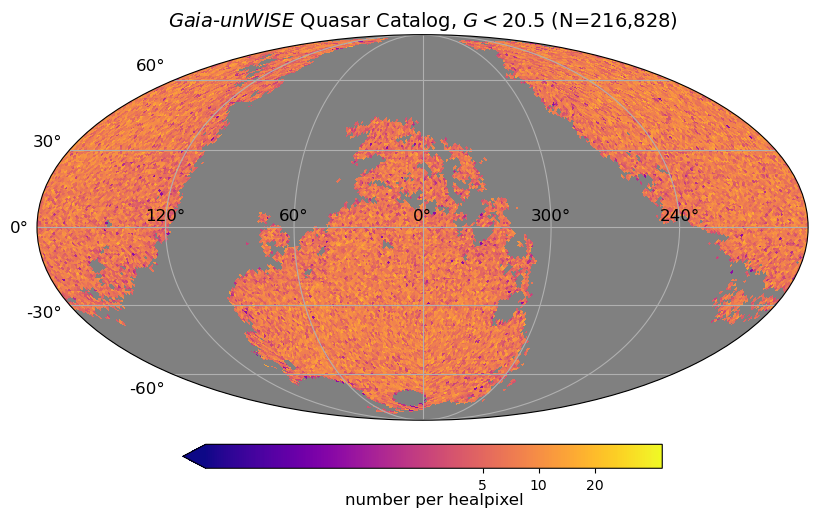

In [285]:
fac_stdev = 0.85
map_gcatlo = np.bincount(pixel_indices_datahi_bin0[pixel_indices_datahi_bin0_mask], minlength=NPIX)
print(np.mean(map_gcatlo)-fac_stdev*np.std(map_gcatlo), np.mean(map_gcatlo)+fac_stdev*np.std(map_gcatlo))
title_gcatlo = rf"{name_catalog}, $G<{G_hi}$ (N={N_gcatlo_mask:,})"
projview(map_gcatlo*hp.pixelfunc.nside2pixarea(NSIDE, degrees = True), title=title_gcatlo,
            unit=r"number per healpixel", cmap=cmap_map, coord=['C'], 
            min=np.mean(map_gcatlo)-fac_stdev*np.std(map_gcatlo), max=np.mean(map_gcatlo)+10*fac_stdev*np.std(map_gcatlo), 
            norm='log', graticule=True, cbar_ticks=cbar_ticks, graticule_labels=True)

In [286]:
len(mask_datahi_bin0[mask_datahi_bin0==True]), len(pixel_indices_datahi_bin0_mask), len(tab_datahi_mask_zbin0)

(216828, 216828, 216828)

In [287]:
np.logical_and(pixel_indices_datahi_bin0_mask, mask_datahi_bin0[mask_datahi_bin0==True])

True
True
True
True
True
True
True
True
True
True
True


In [288]:
idx = np.where(selfunc_hi_bin0==np.max(selfunc_hi_bin0))[0]

In [289]:
tab_datahi_mask_zbin0[pixel_indices_datahi_bin0==idx]

source_id,unwise_objid,redshift_quaia,redshift_quaia_err,ra,dec,l,b,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,mag_w1_vg,mag_w2_vg,pm,pmra,pmdec,pmra_error,pmdec_error
,,,,deg,deg,deg,deg,mag,mag,mag,mag,mag,mas / yr,mas / yr,mas / yr,mas / yr,mas / yr
int64,bytes16,float64,float64,float64,float64,float64,float64,float32,float32,float32,float64,float64,float64,float64,float64,float32,float32
4659543602069460736,0909m682o0102567,2.069437026977539,0.3055113648986818,89.56754065652177,-67.69662222623369,277.69595967552095,-29.96863056509272,20.434946,20.492119,20.590353,17.489223,17.005814,2.615183862901093,1.5825739739080442,2.0819813288997535,0.70127624,0.93483675
4659551607883806976,0909m682o0068884,2.481391191482544,0.1752999999999998,89.40431235705762,-67.54970780980548,277.5277362389841,-30.0336027284455,20.154392,20.680971,19.602188,16.75351,16.017618,0.5073847925763924,0.5050162976248402,-0.04896801886014506,0.43545213,0.562065
4659552642963662592,0909m682o0053299,2.204,0.17082673858642572,89.47499956863071,-67.49707939148708,277.46636855933474,-30.00758863217817,20.307064,20.433315,20.134193,17.339222,16.807154,1.9103558677301968,1.539352251429442,1.1313064073849763,0.5595619,0.5500823
4659554876347300608,0909m682o0125077,2.268,0.25627930553436284,89.0852459929407,-67.66907095348078,277.6689057572342,-30.15234795953651,20.47792,20.562414,20.202913,17.670872,17.132713,2.1656042138727325,2.066464023232176,0.647740728864895,0.74532044,0.68210644
4659569990341057792,0890m667o0075088,2.291045665740967,0.05300000000000016,88.82063227578647,-67.31000006813933,277.25668537464514,-30.26318701229298,20.39783,20.57406,20.031153,17.498741,16.470375,0.9663303870337546,-0.3596150010605177,0.8969233344701485,0.8294159,0.6728435
4659619262236012288,0890m667o0078053,2.345,0.6822214889526368,88.32390858358198,-67.20781817488816,277.14509976655575,-30.45822812468569,20.320242,20.655506,19.567627,16.87836,16.227657,1.4247719537099377,0.06196582489214246,1.423423814829536,0.8839451,0.7120617
4659620194216492288,0890m667o0010544,2.435103178024292,0.4098947725868226,88.26972315193471,-67.14013897220525,277.06745251082197,-30.48154184218849,20.43723,20.586306,20.128658,16.591635,15.914306,2.8060946038451307,2.611271623910094,-1.027339978726955,1.2467333,1.1615726
4659630914468136448,0890m667o0079300,2.5738134384155273,0.12031332637786862,87.24694179305072,-67.15736482836947,277.10711475496254,-30.877631534507753,20.092613,20.230516,19.609,17.0212,15.921063,0.5421528655112074,-0.4922832229798992,0.22712762481595292,0.63950044,0.63412315


## Sanity check at pixel level

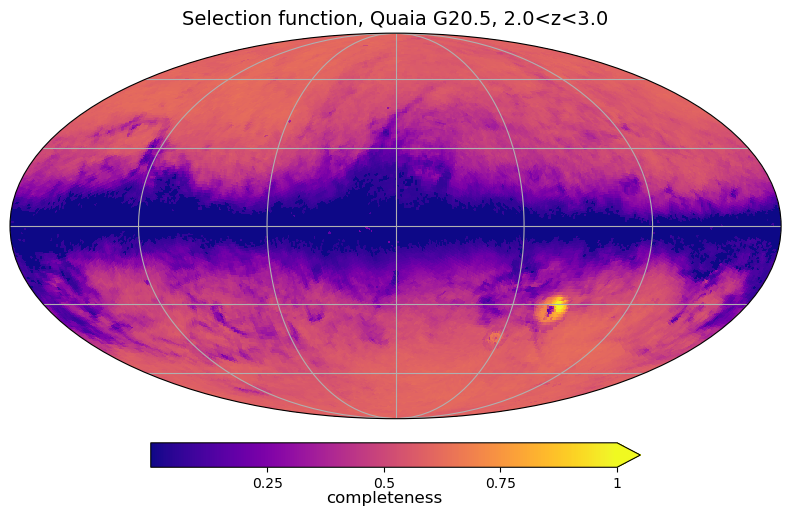

In [296]:
projview(selfunc_hi_bin0, title=f"Selection function, Quaia G{G_hi}, {z_bins[j]}<z<{z_bins[j+1]}",
         unit="completeness", cmap=cmap_map, coord=['C', 'G'], 
         graticule=True, 
         min=0.0, max=1.0,
         cbar_ticks=[0.25, 0.5, 0.75, 1.0]
        )

In [291]:
theta, phi = hp.pix2ang(NSIDE, range(len(selfunc_hi_bin0)), lonlat=True)

In [292]:
c = SkyCoord(ra=theta*u.degree, dec=phi*u.degree)
LMC_idx, _, _, _ = SkyCoord.search_around_sky(LMC, c, LMC_radius)
SMC_idx, _, _, _ = SkyCoord.search_around_sky(SMC, c, SMC_radius)
MC_idx = np.append(LMC_idx,SMC_idx)

In [294]:
MC_idx

array([46064, 46065, 46066, 46067, 46068, 46069, 46217, 46218, 46219,
       46220, 46221, 46222, 46223, 46224, 46225, 46226, 46367, 46368,
       46369, 46370, 46371, 46372, 46373, 46374, 46375, 46376, 46377,
       46378, 46514, 46515, 46516, 46517, 46518, 46519, 46520, 46521,
       46522, 46523, 46524, 46525, 46526, 46656, 46657, 46658, 46659,
       46660, 46661, 46662, 46663, 46664, 46665, 46666, 46667, 46668,
       46669, 46670, 46795, 46796, 46797, 46798, 46799, 46800, 46801,
       46802, 46803, 46804, 46805, 46806, 46807, 46808, 46809, 46930,
       46931, 46932, 46933, 46934, 46935, 46936, 46937, 46938, 46939,
       46940, 46941, 46942, 46943, 46944, 46945, 47061, 47062, 47063,
       47064, 47065, 47066, 47067, 47068, 47069, 47070, 47071, 47072,
       47073, 47074, 47075, 47076, 47188, 47189, 47190, 47191, 47192,
       47193, 47194, 47195, 47196, 47197, 47198, 47199, 47200, 47201,
       47202, 47203, 47311, 47312, 47313, 47314, 47315, 47316, 47317,
       47318, 47319,

In [295]:
MC_mask = np.full_like(range(len(selfunc_hi_bin0)), True, dtype = bool)
MC_mask[MC_idx] = False

In [303]:
selfunc_hi_bin0_masked = np.copy(selfunc_hi_bin0)
selfunc_hi_bin0_masked[MC_mask]=0

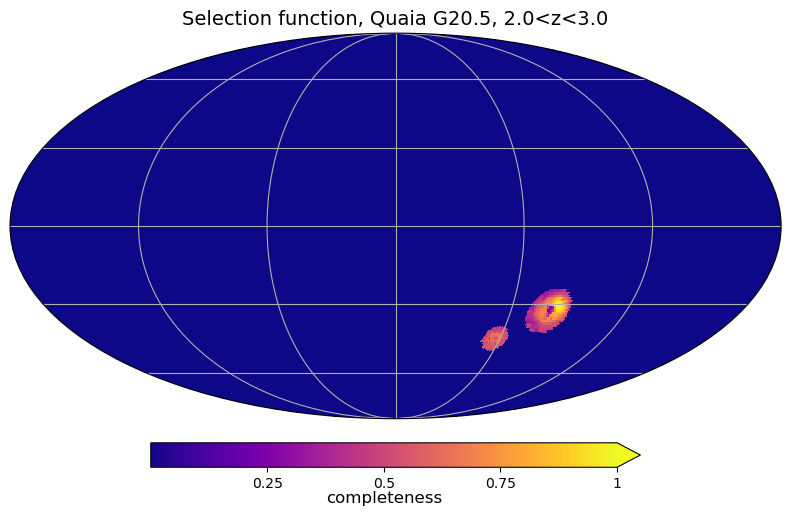

In [304]:
projview(selfunc_hi_bin0_masked, title=f"Selection function, Quaia G{G_hi}, {z_bins[j]}<z<{z_bins[j+1]}",
         unit="completeness", cmap=cmap_map, coord=['C', 'G'], 
         graticule=True, 
         min=0.0, max=1.0,
         cbar_ticks=[0.25, 0.5, 0.75, 1.0]
        )

In [305]:
selfunc_hi_bin0_masked = np.copy(selfunc_hi_bin0)
selfunc_hi_bin0_masked[~MC_mask]=0

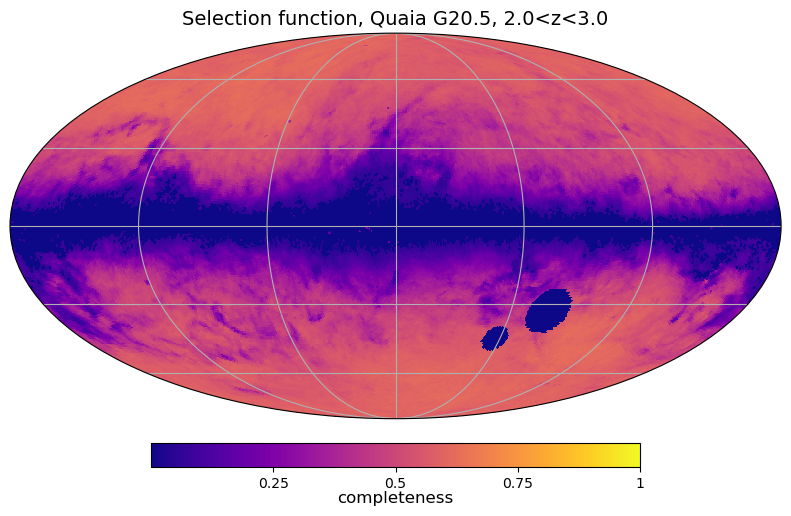

In [306]:
projview(selfunc_hi_bin0_masked, title=f"Selection function, Quaia G{G_hi}, {z_bins[j]}<z<{z_bins[j+1]}",
         unit="completeness", cmap=cmap_map, coord=['C', 'G'], 
         graticule=True, 
         min=0.0, max=1.0,
         cbar_ticks=[0.25, 0.5, 0.75, 1.0]
        )

## Test that I implemented it right

In [341]:
import importlib
importlib.reload(quaia)

<module 'quaia' from '/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py'>

In [342]:
j = 2
tab_datahi_mask_zbin0, _, _, _, _, _, selfunc_hi_bin0, mask_datahi_bin0, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0: 0.25              213734 vs 286508


In [343]:
pixel_indices_datahi_bin0 = hp.ang2pix(NSIDE, tab_datahi_mask_zbin0['ra'], tab_datahi_mask_zbin0['dec'], lonlat=True)

0.16177501908387448 8.53508370487446


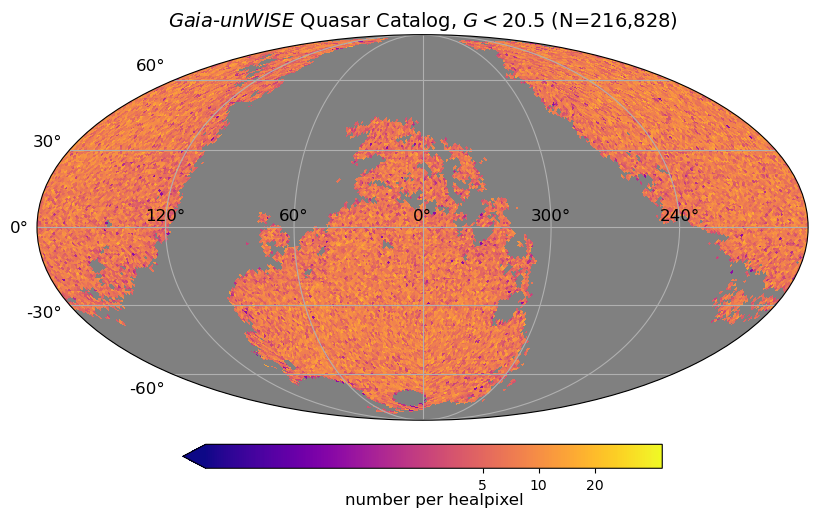

In [344]:
map_gcatlo = np.bincount(pixel_indices_datahi_bin0, minlength=NPIX)
print(np.mean(map_gcatlo)-fac_stdev*np.std(map_gcatlo), np.mean(map_gcatlo)+fac_stdev*np.std(map_gcatlo))
title_gcatlo = rf"{name_catalog}, $G<{G_hi}$ (N={N_gcatlo_mask:,})"
projview(map_gcatlo*hp.pixelfunc.nside2pixarea(NSIDE, degrees = True), title=title_gcatlo,
            unit=r"number per healpixel", cmap=cmap_map, coord=['C'], #, 'G']
            min=np.mean(map_gcatlo)-fac_stdev*np.std(map_gcatlo), max=np.mean(map_gcatlo)+10*fac_stdev*np.std(map_gcatlo), 
            norm='log', graticule=True, cbar_ticks=cbar_ticks, graticule_labels=True)

In [345]:
np.max(selfunc_hi_bin0)

1.6779283485697618

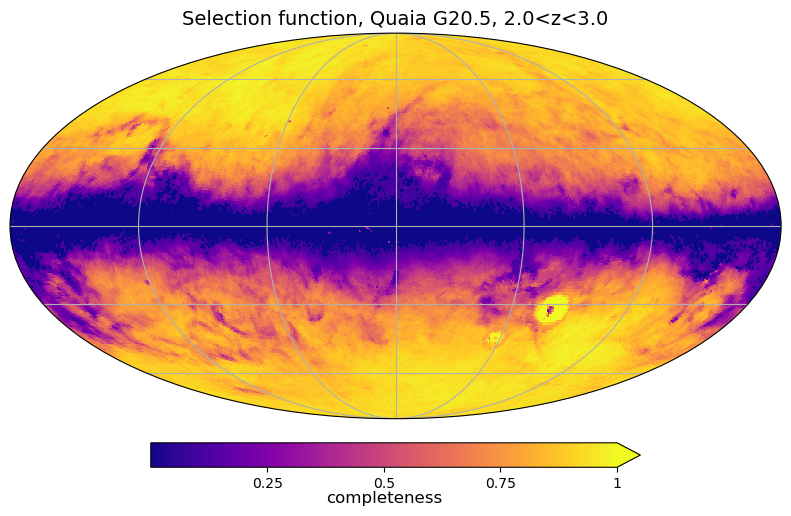

In [346]:
projview(selfunc_hi_bin0, title=f"Selection function, Quaia G{G_hi}, {z_bins[j]}<z<{z_bins[j+1]}",
         unit="completeness", cmap=cmap_map, coord=['C', 'G'], 
         graticule=True, 
         min=0.0, max=1.0,
         cbar_ticks=[0.25, 0.5, 0.75, 1.0]
        )

# Calculate number density as $n_q \approx \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle$

In [113]:
tab_datahi_mask_zbins, selfunc_hi_bins = [], []
for j in z_array:
    
    tab_datahi_mask_zbin0, _, _, _, _, _, selfunc_hi_bin0, _, pixel_indices_datahi_bin0 = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)
    tab_datahi_mask_zbins.append(tab_datahi_mask_zbin0['redshift_quaia'])
    selfunc_hi_bins.append(selfunc_hi_bin0)

Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0: 0.31              223881 vs 324336
Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0: 0.28              464213 vs 648196
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0: 0.25              213734 vs 286508
Pixels masked by MC but not already by selfunc: 350
G20.5_zmin3.0zmax4.6: 0.22              28436 vs 36458


In [114]:
# n_q, n_q_err, V_eff, N_q = [], [], [], []

# for j in z_array:
    
#     N = len(tab_datahi_mask_zbins[j])
#     cp = np.percentile(selfunc_hi_bins[j], mask*100)
#     f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_hi_bins[j]>=cp]*hp.nside2pixarea(NSIDE))
#     print(f_sky) # f_sky)
#     V = f_sky*(Planck18.comoving_volume(z_bins[j+1])-Planck18.comoving_volume(z_bins[j]))*Planck18.h**3/u.h**3
#     N_q.append(N)
#     n_q.append(N/V.value)
#     n_q_err.append(np.sqrt(N)/V.value) # Poisson error
#     V_eff.append(V)
    
# n_q

In [115]:
LMC = SkyCoord(['05 23 34.6 -69 45 22'], unit=(u.hourangle, u.deg)) #https://simbad.u-strasbg.fr/simbad/sim-id?Ident=Large+Magellanic+Cloud

In [116]:
LMC_radius = 9*u.deg

In [117]:
SMC = SkyCoord(['00 52 38.0 -72 48 01'], unit=(u.hourangle, u.deg)) # https://simbad.u-strasbg.fr/simbad/sim-id?Ident=small+Magellanic+Cloud

In [118]:
SMC_radius = 5*u.deg

In [119]:
n_q, n_q_err, V_eff, N_q = [], [], [], []

for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    cp = np.percentile(selfunc_hi_bins[j], mask*100)
    selfunc_mask = selfunc_hi_bins[j]>=cp
    theta, phi = hp.pix2ang(NSIDE, range(len(selfunc_hi_bins[j])), lonlat=True)
    c = SkyCoord(ra=theta*u.degree, dec=phi*u.degree)
    LMC_idx, _, _, _ = SkyCoord.search_around_sky(LMC, c, LMC_radius)
    SMC_idx, _, _, _ = SkyCoord.search_around_sky(SMC, c, SMC_radius)
    MC_idx = np.append(LMC_idx,SMC_idx)
    MC_mask = np.full_like(range(len(selfunc_hi_bins[j])), True, dtype = bool)
    MC_mask[MC_idx] = False
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_mask & MC_mask]*hp.nside2pixarea(NSIDE))
    print(f_sky) # f_sky)
    V = f_sky*(Planck18.comoving_volume(z_bins[j+1])-Planck18.comoving_volume(z_bins[j]))*Planck18.h**3/u.h**3
    N_q.append(N)
    n_q.append(N/V.value)
    n_q_err.append(np.sqrt(N)/V.value) # Poisson error
    V_eff.append(V)
    
n_q

0.3812326432060453
0.39892696555786405
0.4240188533529075
0.4349358620974798


[1.1560583824125186e-05,
 8.122876991671759e-06,
 3.0941145087989882e-06,
 2.7241521338797804e-07]

In [120]:
fduty_err_hi = 0.002, 0.001, 0.008, 0.077
fduty_err_lo = 0.002, 0.001, 0.007, 0.034

In [121]:
def n_q_theory_err(n_dm, fduty_err, M_min, a, M_min_err, hmf = hmf, cosmo = cosmo_planck18): #quaia):
    
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.sqrt(n_dm**2*fduty_err**2+(fduty_err*hmf(cosmo, 10**M_min, a))**2*M_min_err**2)

## Limit scales to $30\geq s \geq 80h^{-1}$ Mpc

In [122]:
# Create the bins array
offset = 2.5
delta_max = 40# 64
delta_min = np.min((np.floor((30-0.15)/offset), delta_max))

rmin = 30-delta_min*offset # 0.1 # start higher # 1.4 # 30
rmax = 80+delta_max*offset # 200
nbins = 20 + int(delta_min+delta_max) #90 #20
rbins_chi2 = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
rbins_chi2, quaia.recenter(rbins_chi2), np.diff(quaia.recenter(rbins_chi2))

(array([  2.5,   5. ,   7.5,  10. ,  12.5,  15. ,  17.5,  20. ,  22.5,
         25. ,  27.5,  30. ,  32.5,  35. ,  37.5,  40. ,  42.5,  45. ,
         47.5,  50. ,  52.5,  55. ,  57.5,  60. ,  62.5,  65. ,  67.5,
         70. ,  72.5,  75. ,  77.5,  80. ,  82.5,  85. ,  87.5,  90. ,
         92.5,  95. ,  97.5, 100. , 102.5, 105. , 107.5, 110. , 112.5,
        115. , 117.5, 120. , 122.5, 125. , 127.5, 130. , 132.5, 135. ,
        137.5, 140. , 142.5, 145. , 147.5, 150. , 152.5, 155. , 157.5,
        160. , 162.5, 165. , 167.5, 170. , 172.5, 175. , 177.5, 180. ]),
 array([  3.75,   6.25,   8.75,  11.25,  13.75,  16.25,  18.75,  21.25,
         23.75,  26.25,  28.75,  31.25,  33.75,  36.25,  38.75,  41.25,
         43.75,  46.25,  48.75,  51.25,  53.75,  56.25,  58.75,  61.25,
         63.75,  66.25,  68.75,  71.25,  73.75,  76.25,  78.75,  81.25,
         83.75,  86.25,  88.75,  91.25,  93.75,  96.25,  98.75, 101.25,
        103.75, 106.25, 108.75, 111.25, 113.75, 116.25, 118.75, 121.25

## Compute the maximum number of jackknife regions

In [123]:
for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    cp = np.percentile(selfunc_hi_bins[j], mask*100)
    selfunc_mask = selfunc_hi_bins[j]>=cp
    theta, phi = hp.pix2ang(NSIDE, range(len(selfunc_hi_bins[j])), lonlat=True)
    c = SkyCoord(ra=theta*u.degree, dec=phi*u.degree)
    LMC_idx, _, _, _ = SkyCoord.search_around_sky(LMC, c, LMC_radius)
    SMC_idx, _, _, _ = SkyCoord.search_around_sky(SMC, c, SMC_radius)
    MC_idx = np.append(LMC_idx,SMC_idx)
    MC_mask = np.full_like(range(len(selfunc_hi_bins[j])), True, dtype = bool)
    MC_mask[MC_idx] = False
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_mask & MC_mask]*hp.nside2pixarea(NSIDE))
    # f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_hi_bins[j]>=cp]*hp.nside2pixarea(NSIDE))
    V = f_sky*(Planck18.comoving_volume(j+1)-Planck18.comoving_volume(j))*Planck18.h**3/u.h**3
    V_jackknife = f_sky*(4/3*np.pi*(rmax**3))*V.unit
    print(np.int(V/V_jackknife), (V/25)**(1/3))

2079 918.4012950330948 Mpc / h
5864 1317.3134853785514 Mpc / h
6668 1403.241459100361 Mpc / h
6319 1390.0450834650237 Mpc / h


In [124]:
cf_chi2, cf_matter_chi2 = [], []
yerr_cf_chi2, b_cf_chi2 = [], []
b_cf_q_chi2 = []
a_zbin = []
H0 = Planck18.H0 # cosmo_planck18['H0'] * u.km/u.s/u.Mpc
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins_chi2, Om0 = Planck18.Om0, h = Planck18.h, error = True)
    cf_chi2.append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)
    a_zbin.append(a)

    # matter correlation function
    rbins_Mpc = (quaia.recenter(rbins_chi2)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmo_planck18, r=rbins_Mpc, a=a)
    cf_matter_chi2.append(cf_matter)

    # effective bias 
    b = np.sqrt(cf/cf_matter)
    b_cf_chi2.append(b)

    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf_chi2.append(yerr)

    # qso bias
    b_cf_q_chi2.append(b_qso(cf, cf_matter, ccl.growth_rate(cosmo_planck18, a)))

Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0: 0.31              223881 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_250170/4246606042.py:29: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_250170/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0: 0.28              464213 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_250170/4246606042.py:29: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_250170/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0: 0.25              213734 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_250170/4246606042.py:29: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_250170/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


Pixels masked by MC but not already by selfunc: 350
G20.5_zmin3.0zmax4.6: 0.22              28436 vs 36458


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_250170/4246606042.py:29: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_250170/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


In [125]:
rpmask = (quaia.recenter(rbins_chi2) >= 30) & (quaia.recenter(rbins_chi2) <= 80)

# Perform nested sampling with dynesty

In [126]:
# Define the dimensionality of our problem.
ndim = 2

## Pick cosmology

In [127]:
cosmo = 'Planck'

In [128]:
N = 85

In [129]:
# Define our 3-D correlated multivariate normal log-likelihood.
# C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, 30, 80, 20, j)) # very bad
# C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_Planck.npy'.format(G_hi, 30, 80, 20, j)) # good
# C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N25_cosmo_planck18.npy'.format(G_hi, 30, 80, 20, z_bins[j], z_bins[j+1])) # bad
# C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, rmin, rmax, nbins, j, cosmo)) # [np.ix_([False]+[True]*20+[False], [False]+[True]*20+[False])] # very good
# C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N25_{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], cosmo)) # bad
# C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good

# C[C==0] = 0.95
ix_grid = np.ix_(rpmask, rpmask)
    
def loglike(x, a, cf_matter, C, cf, n_q, nbins, cosmo = cosmo_planck18, error = 0.05):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*10**fduty
    # n_m=np.ones(np.shape(bins_m))*fduty
        
    cf_2h_zbin, _ = cf_2h(bins_m, n_m, a, cosmo, cf_matter, recenter = False)
    delta = cf-cf_2h_zbin
    
    Cinv = np.linalg.inv(C)
    lnorm = -0.5 * (np.log(2 * np.pi) * nbins +
                    np.log(np.linalg.det(C)))
    
    n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]
    penalty = np.abs(n_q_theory-n_q)/n_q
    if penalty > error:
        penalty = np.inf
    
    return -0.5 * np.dot(delta, np.dot(Cinv, delta)) + lnorm - penalty

In [130]:
def ptform(u):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  # copy u 

    # Uniform from 0 to 1
    # x[0] = u[0] # should this also be uniform in log?
    x[0] =  6* u[0] - 6 # scale and shift to [-6., 0.)


    # Uniform from 9 to 15
    x[1] = 6 * u[1] + 9  # scale and shift to [9., 15.)

    return x

In [131]:
# initialize our nested sampler
sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[j], cf_matter_chi2[j][rpmask], C[ix_grid], cf_chi2[j][rpmask], n_q[j], nbins])

In [132]:
# run the sampler with checkpointing
sampler.run_nested(dlogz = 0.005)
results = sampler.results

3841it [00:18, 207.56it/s, +500 | bound: 17 | nc: 1 | ncall: 34372 | eff(%): 12.816 | loglstar:   -inf < -14.787 <    inf | logz: -21.873 +/-    nan | dlogz:  0.000 >  0.005]


In [133]:
# Print out a summary of the results.
results.summary()

Summary
nlive: 500
niter: 3841
ncall: 9372
eff(%): 12.816
logz: -21.873 +/-  0.114


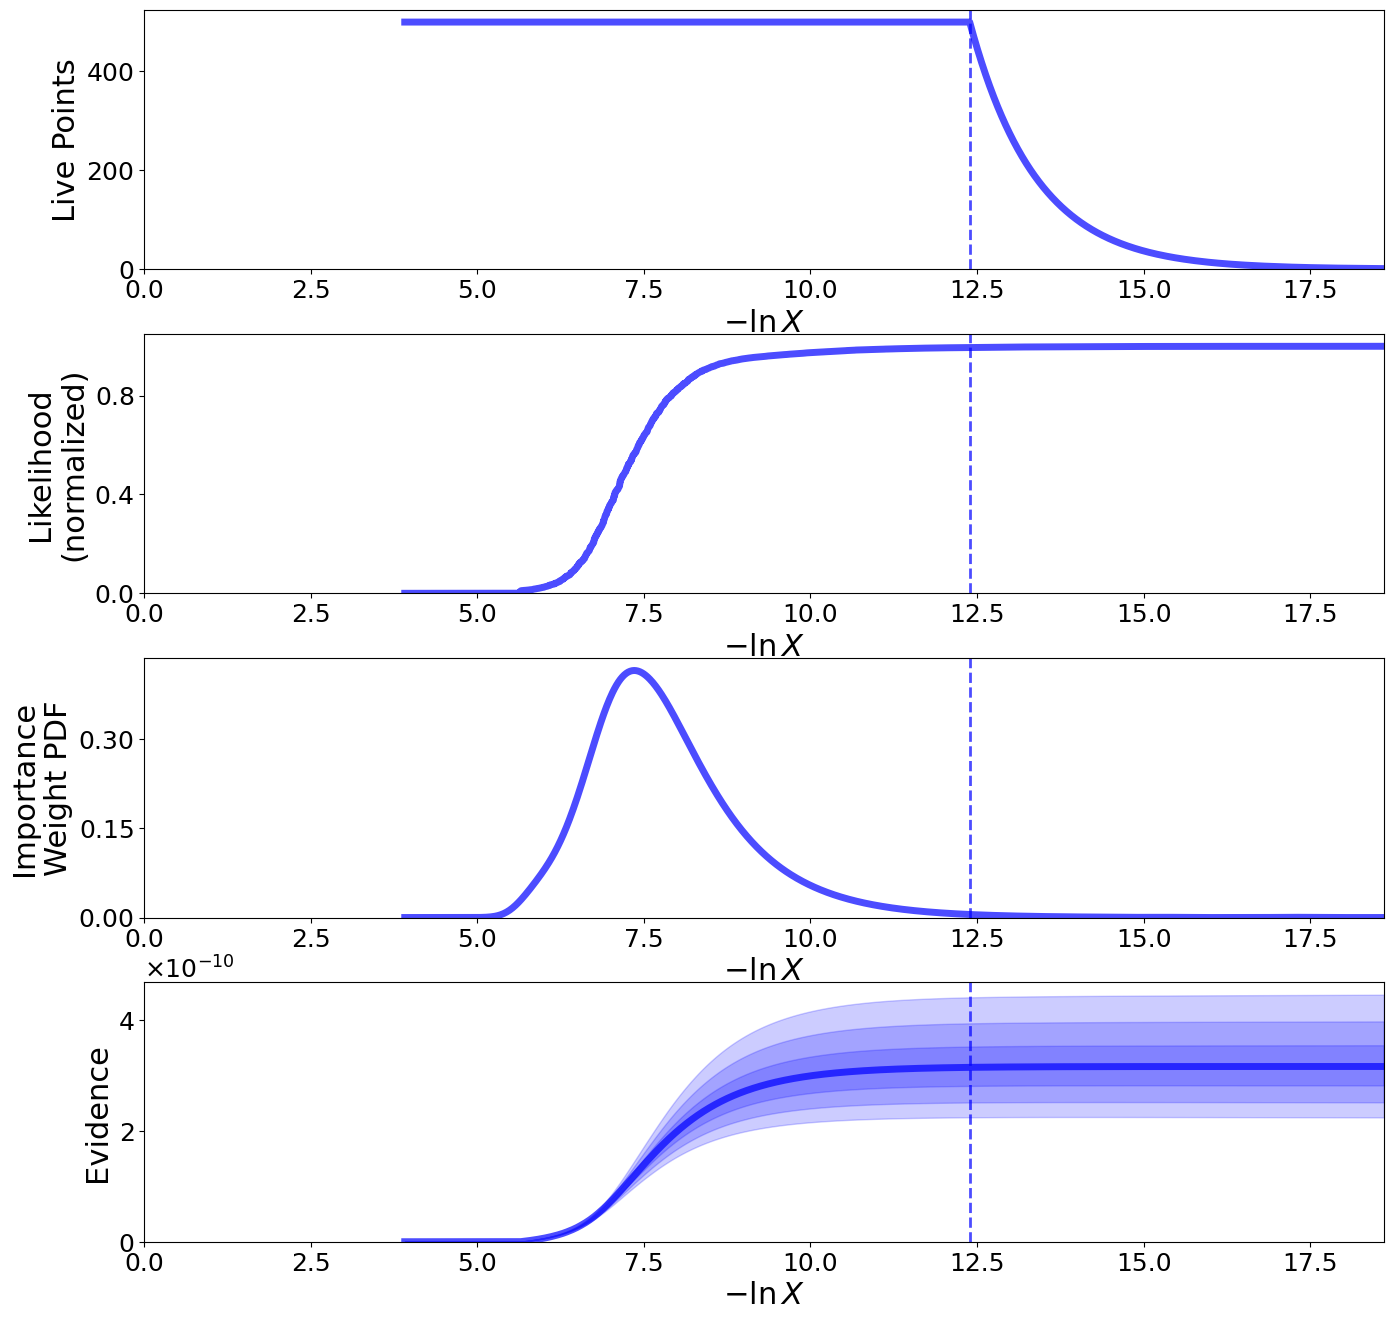

In [134]:
# lnz_truth = ndim * -np.log(2 * 10.)  # analytic evidence solution
fig, axes = dyplot.runplot(results)  # summary (run) plot
fig.subplots_adjust(hspace=0.25)

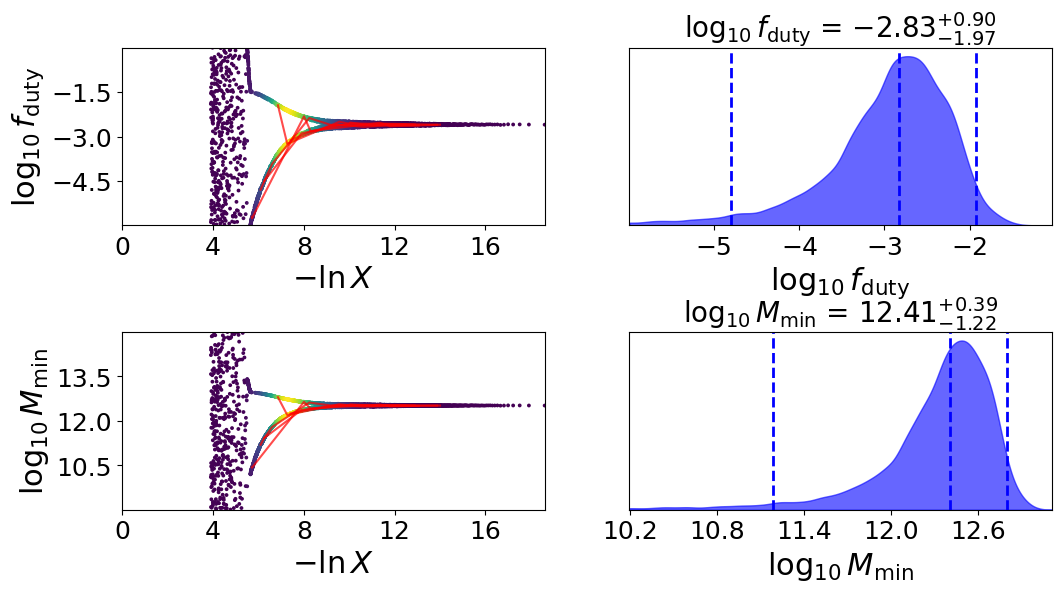

In [135]:
fig, axes = dyplot.traceplot(results, 
                             # truths=np.zeros(ndim),
                             # truth_color='black', 
                             show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5), labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'])
fig.subplots_adjust(hspace=0.6)

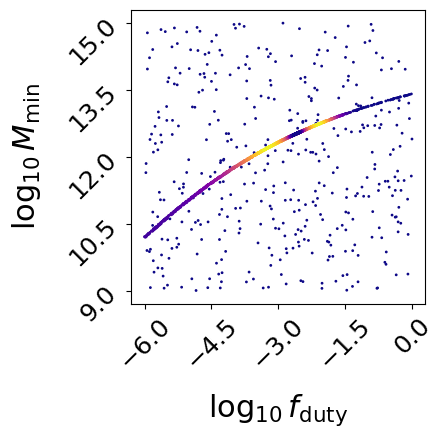

In [136]:
# initialize figure
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
# axes = axes.reshape((2, 2))  # reshape axes

# add white space
# [a.set_frame_on(False) for a in axes[:, 2]]
# [a.set_xticks([]) for a in axes[:, 2]]
# [a.set_yticks([]) for a in axes[:, 2]]

# plot initial run (res1; left)
fg, ax = dyplot.cornerpoints(results, cmap='plasma',
                             # truths=np.zeros(ndim),
                             kde=False, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes))

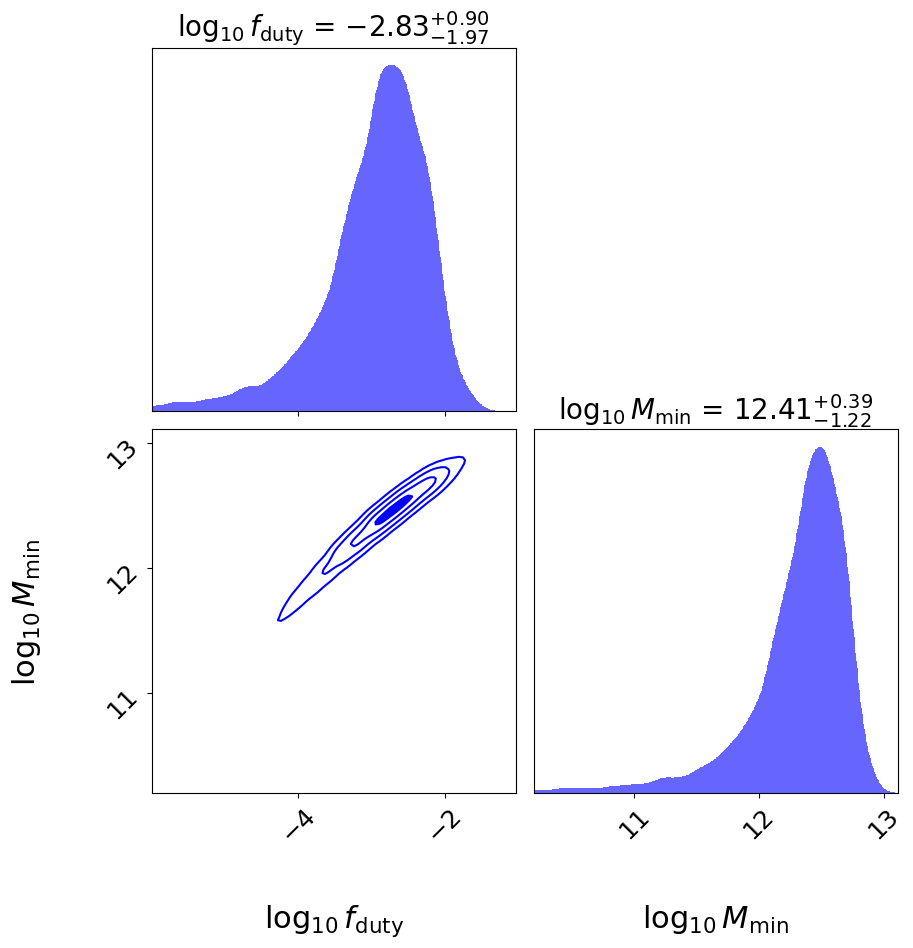

In [137]:
# # initialize figure
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
# axes = axes.reshape((3, 7))  # reshape axes

# # add white space
# [a.set_frame_on(False) for a in axes[:, 3]]
# [a.set_xticks([]) for a in axes[:, 3]]
# [a.set_yticks([]) for a in axes[:, 3]]

# plot initial run (res1; left)
fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                           truth_color='black', show_titles=True,
                           max_n_ticks=3, quantiles=None, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes[:, :3]))
# fg.subplots_adjust(wspace=0.15, hspace=0.15)
# fg.subplots_adjust(hspace=0.3)

In [138]:
samples, weights = results.samples, results.importance_weights()
mean, cov = dyfunc.mean_and_cov(samples, weights)
print(mean, cov)

[-2.95070027 12.31612222] [[0.50847993 0.28390129]
 [0.28390129 0.16142405]]


In [139]:
# Compute weighted quantiles
# weights = np.exp(results.logwt - results.logz[-1])
# samples = results.samples
samples, weights = results.samples, results.importance_weights()

# Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
quantiles = [dyfunc.quantile(samples[:, i], [0.025, 0.5, 0.975], weights=weights) 
             for i in range(samples.shape[1])]
labels = ['log10(f_duty)', 'log10(M_min)']

for i, (lo, mid, hi) in enumerate(quantiles):
    print(f"{labels[i]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")

log10(f_duty): -2.83 + 0.90/-1.97
log10(M_min): 12.41 + 0.39/-1.22


## Across all $z$

4375it [00:27, 158.21it/s, +500 | bound: 19 | nc: 1 | ncall: 25222 | eff(%): 19.719 | loglstar:   -inf < 32.824 <    inf | logz: 25.182 +/-    nan | dlogz:  0.000 >  0.005]


Summary
nlive: 500
niter: 4375
ncall: 10222
eff(%): 19.719
logz: 25.182 +/-  0.121
0<z<=1
log10(f_duty): -2.68 + 0.12/-0.12
log10(M_min): 12.09 + 0.12/-0.13



4597it [00:23, 192.67it/s, +500 | bound: 19 | nc: 1 | ncall: 30717 | eff(%): 16.868 | loglstar:   -inf < 25.595 <    inf | logz: 17.180 +/-    nan | dlogz:  0.000 >  0.005]


Summary
nlive: 500
niter: 4597
ncall: 9717
eff(%): 16.868
logz: 17.180 +/-  0.127
1<z<=2
log10(f_duty): -2.83 + 0.08/-0.10
log10(M_min): 11.98 + 0.07/-0.09



4582it [00:16, 282.59it/s, +500 | bound: 21 | nc: 1 | ncall: 31124 | eff(%): 16.595 | loglstar:   -inf < 23.502 <    inf | logz: 15.133 +/-    nan | dlogz:  0.000 >  0.005]


Summary
nlive: 500
niter: 4582
ncall: 10624
eff(%): 16.595
logz: 15.133 +/-  0.127
2<z<=3
log10(f_duty): -2.66 + 0.13/-0.13
log10(M_min): 12.20 + 0.08/-0.09



3846it [00:15, 240.68it/s, +500 | bound: 17 | nc: 1 | ncall: 30232 | eff(%): 14.617 | loglstar:   -inf < -14.787 <    inf | logz: -21.734 +/-    nan | dlogz:  0.000 >  0.005]


Summary
nlive: 500
niter: 3846
ncall: 8732
eff(%): 14.617
logz: -21.734 +/-  0.113
3<z<=4
log10(f_duty): -2.83 + 0.50/-0.70
log10(M_min): 12.41 + 0.23/-0.36



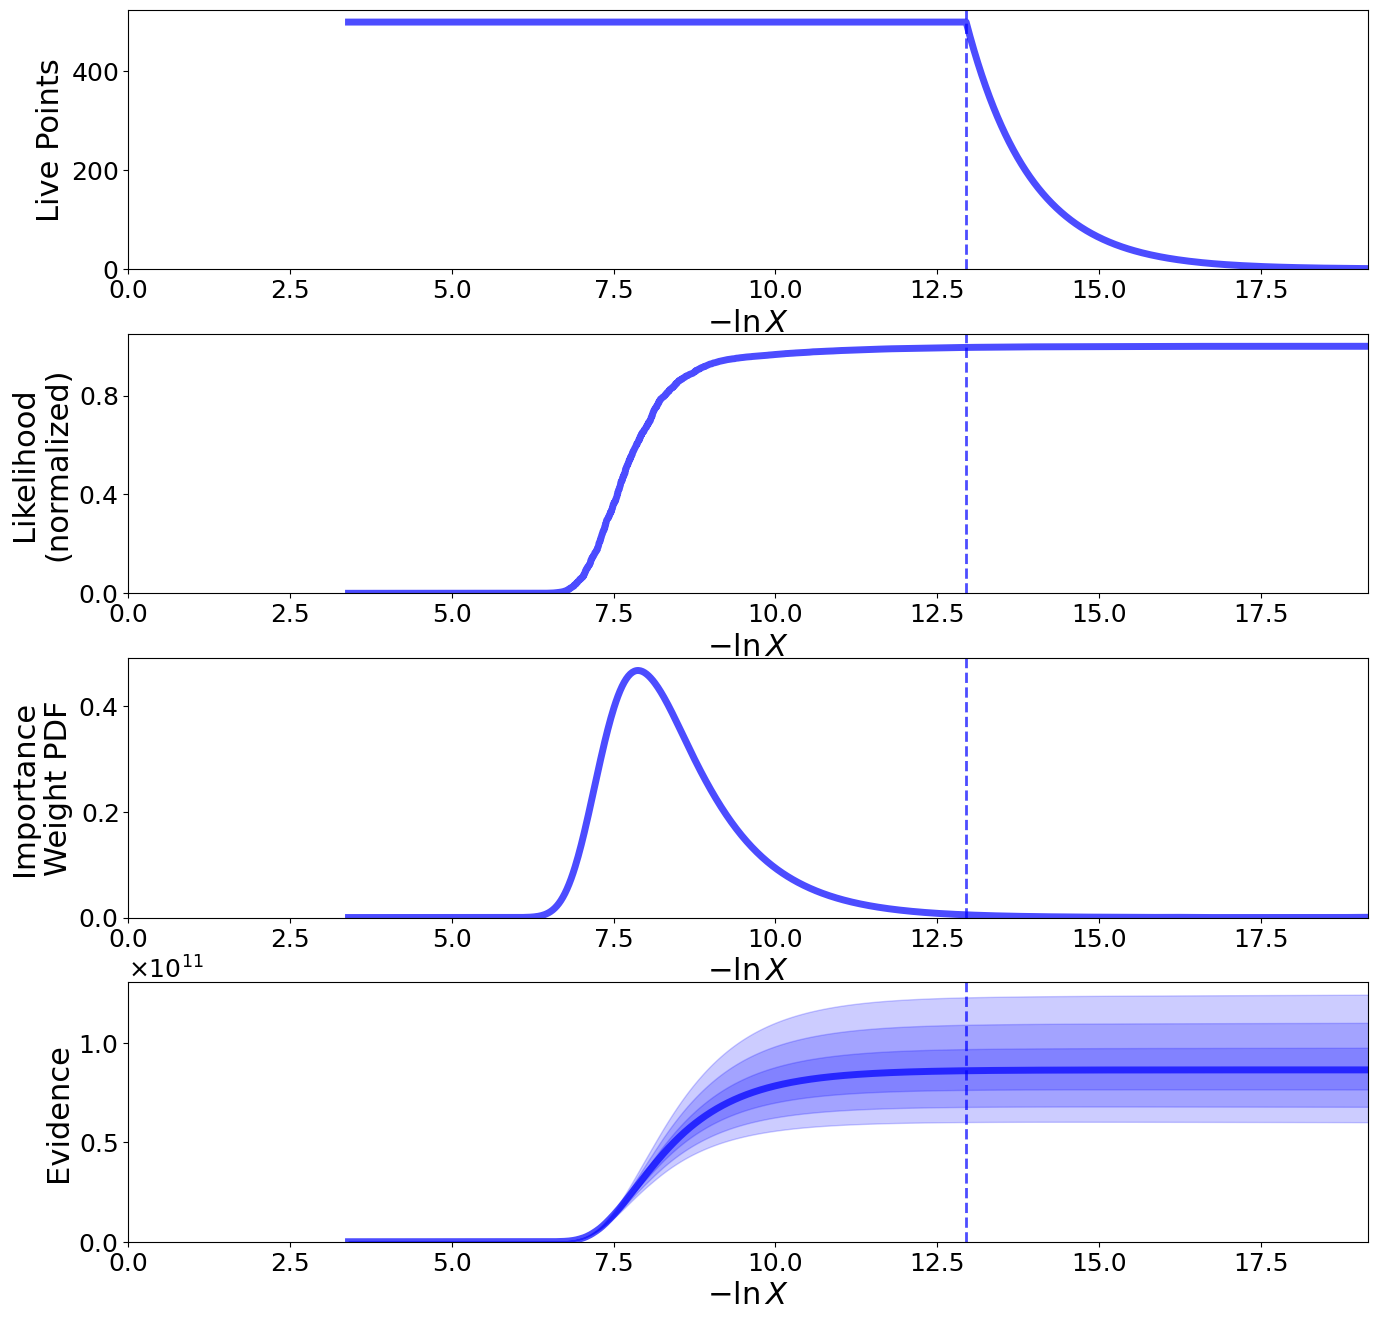

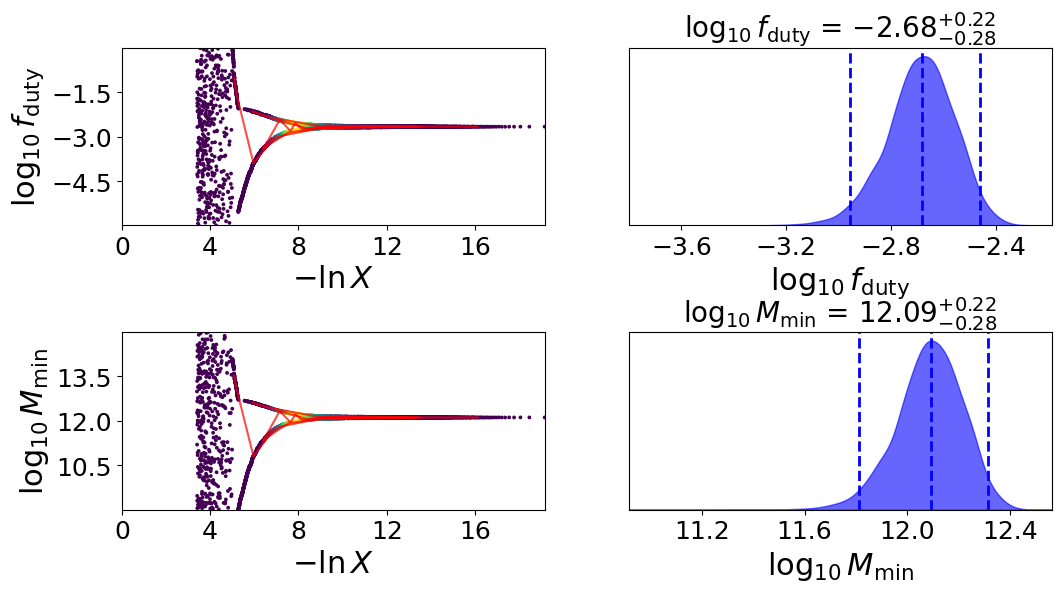

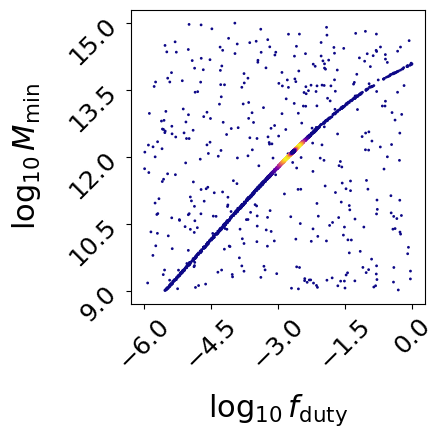

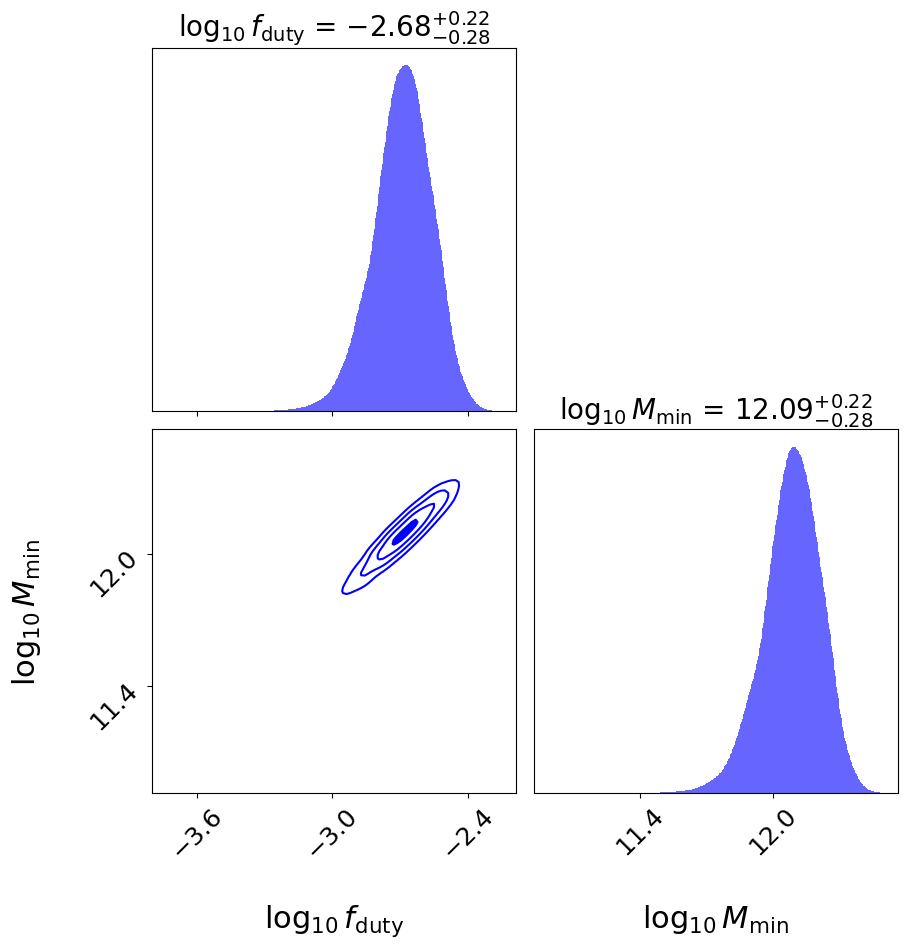

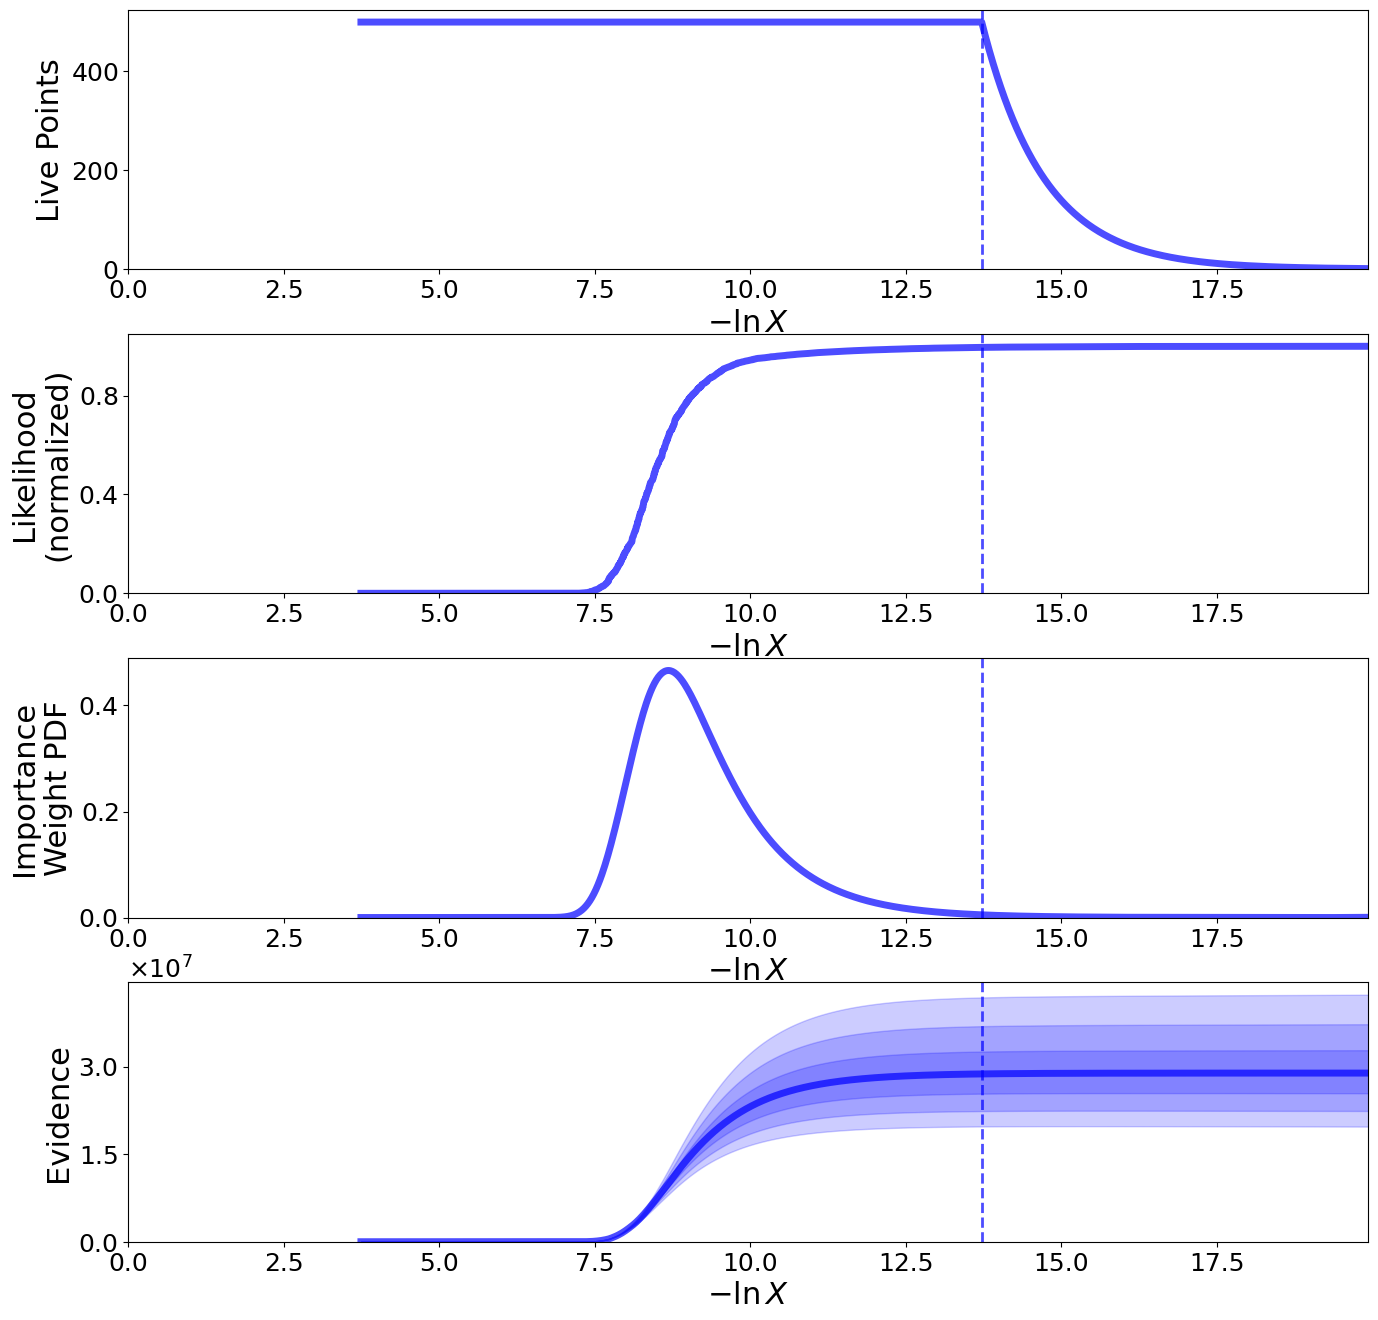

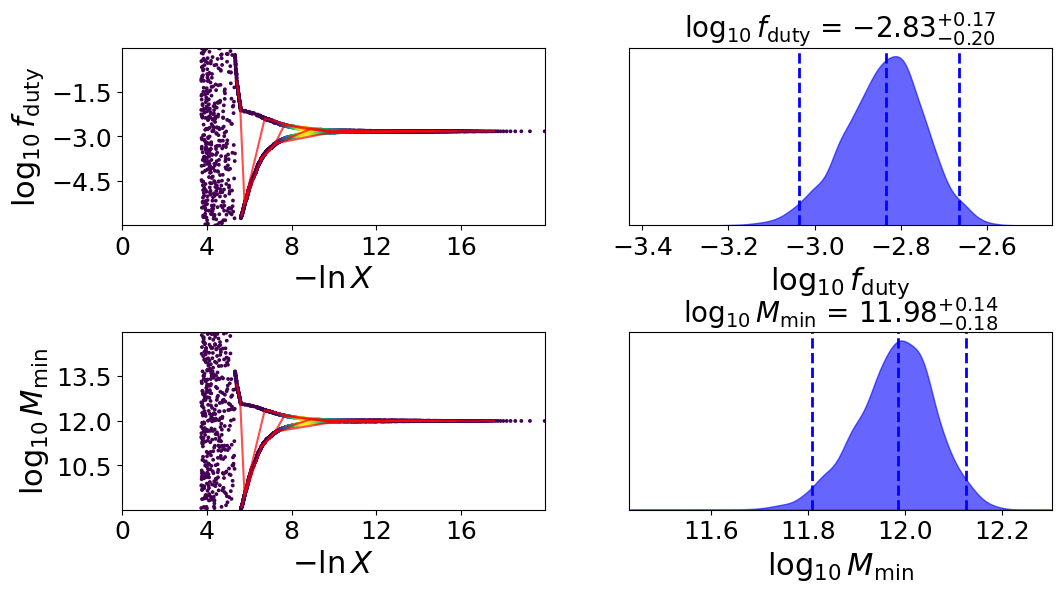

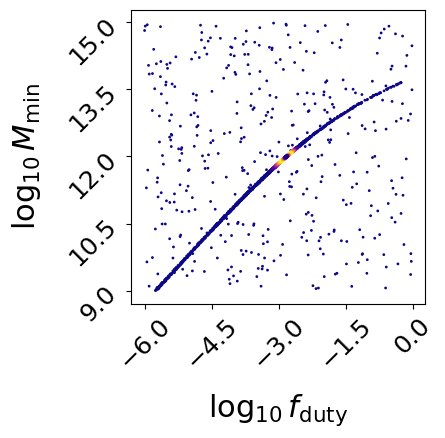

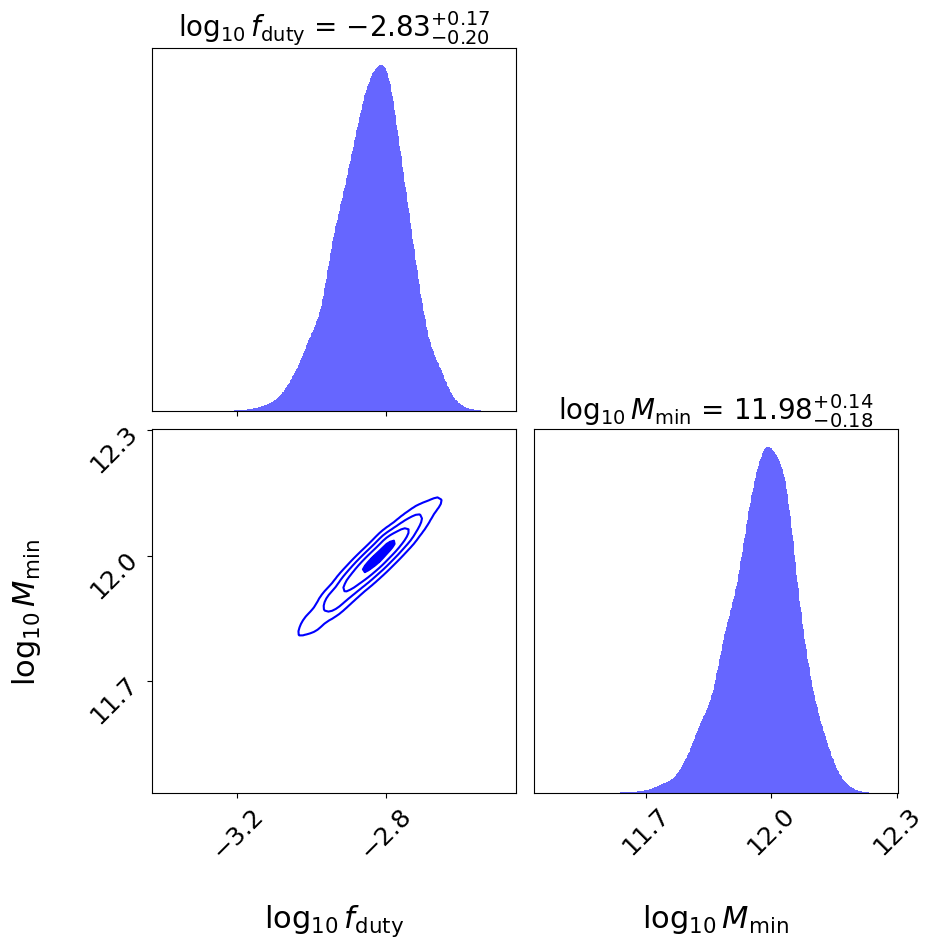

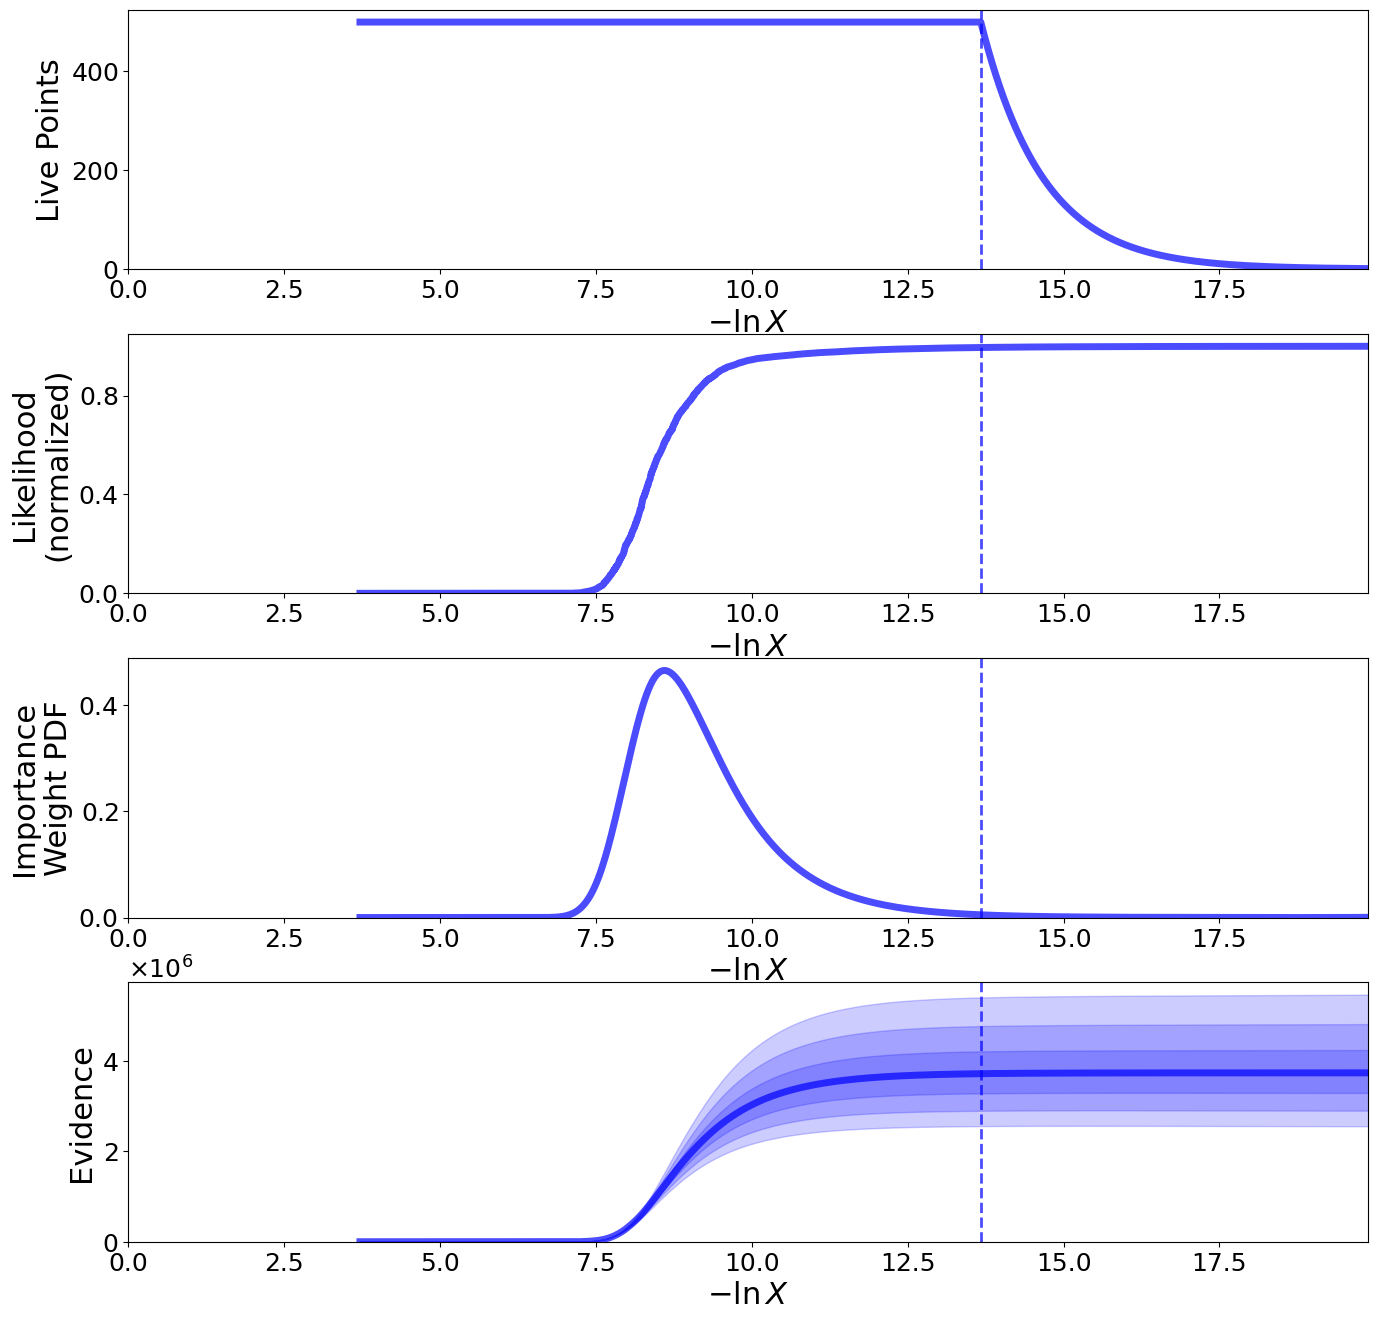

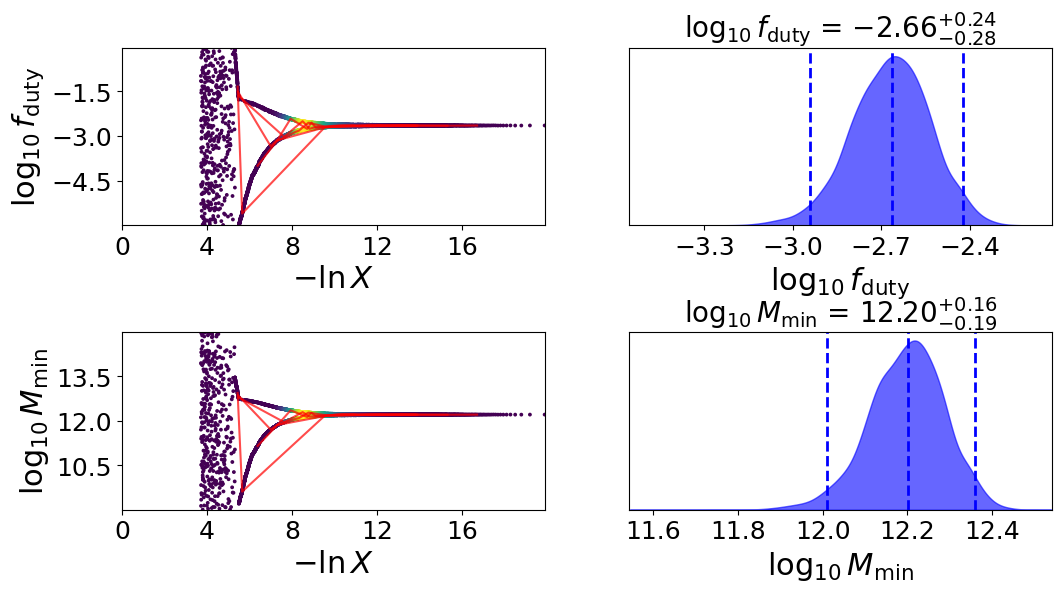

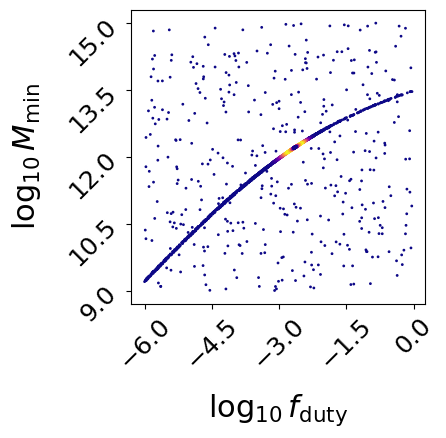

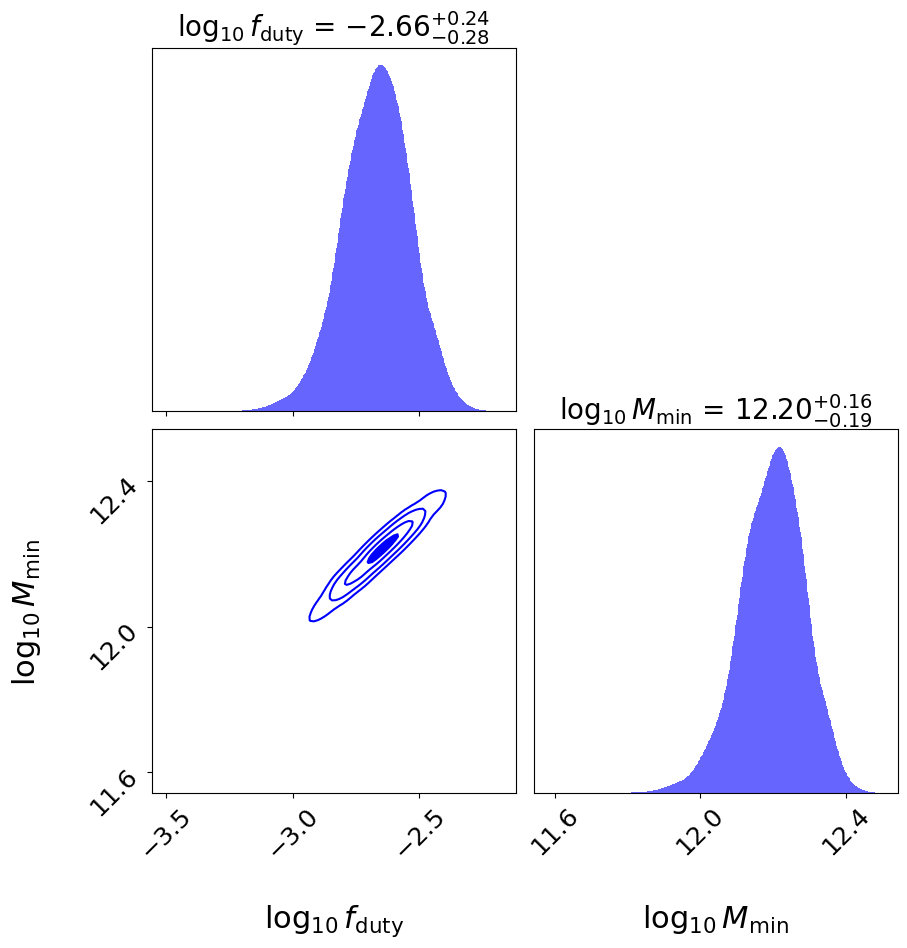

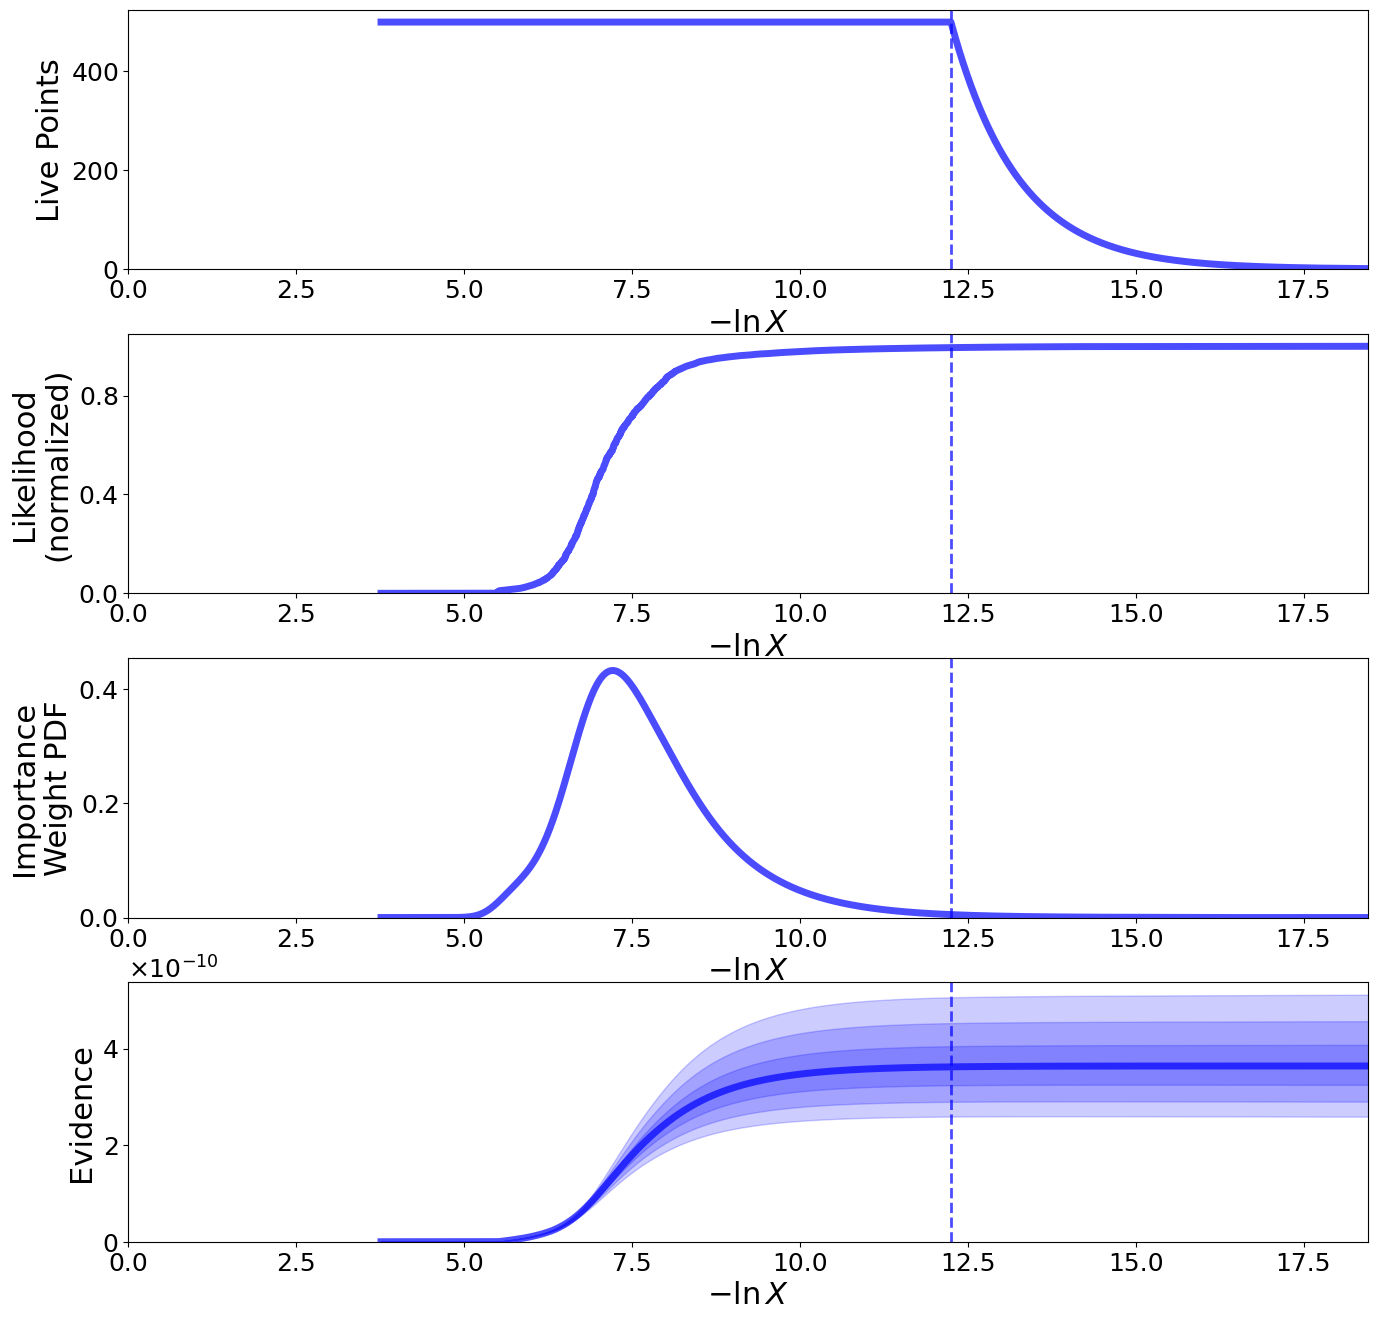

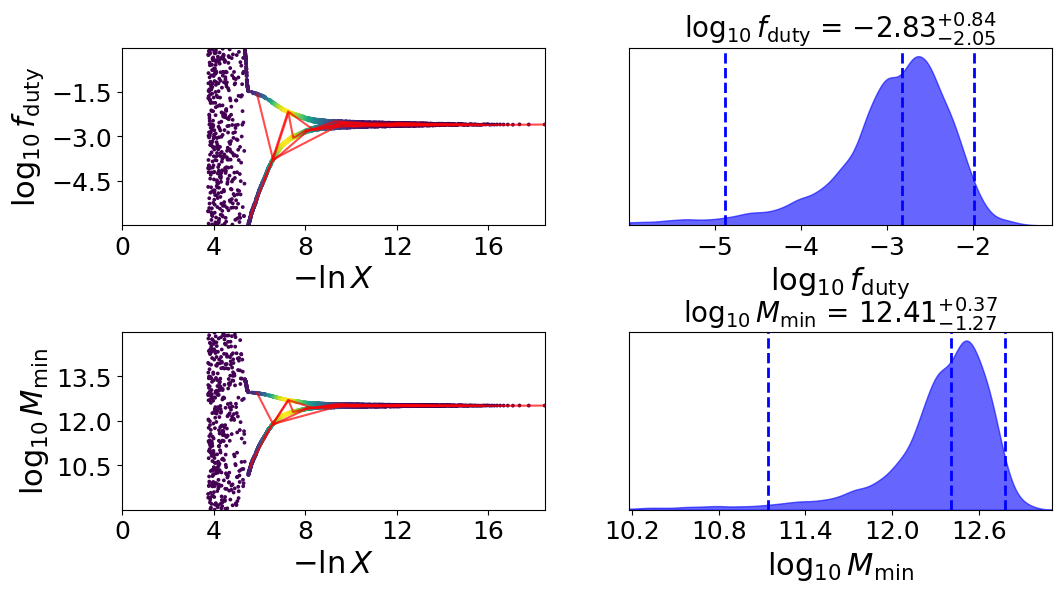

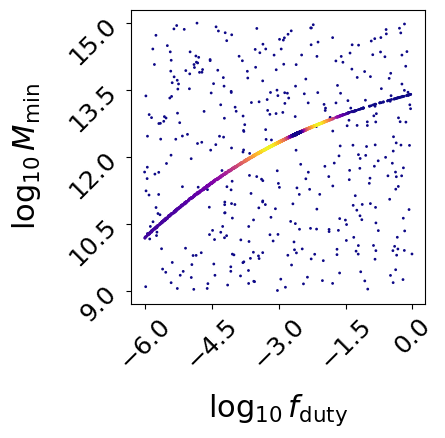

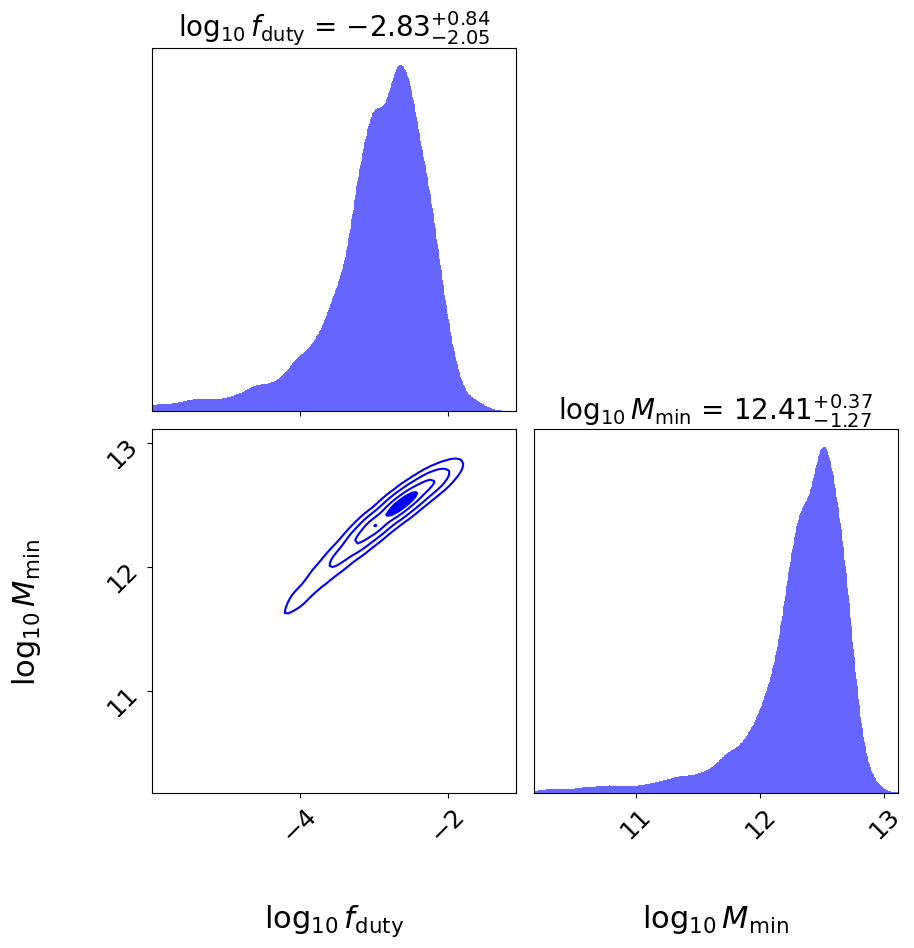

In [140]:
f_duty, M_min = [], []
# f_duty_hi, M_min_hi, f_duty_lo, M_min_lo = [], [], [], []
labels = ['log10(f_duty)', 'log10(M_min)']
err = {i: [] for i in labels}
f_duty_samples, M_min_samples = [], []
for j in z_array:
    
    # C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, 30, 80, 20, j))
    # C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, rmin, rmax, nbins, j, cosmo)) # [np.ix_([False]+[True]*20+[False], [False]+[True]*20+[False])] # very good
    # C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good

    ix_grid = np.ix_(rpmask, rpmask)

    # initialize our nested sampler
    sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[j], cf_matter_chi2[j][rpmask], C[ix_grid], cf_chi2[j][rpmask], n_q[j], nbins])
    
    # run the sampler with checkpointing
    sampler.run_nested(dlogz = 0.005)
    results = sampler.results
    
    # Print out a summary of the results.
    results.summary()
    
    fig, axes = dyplot.runplot(results)  # summary (run) plot
    fig.subplots_adjust(hspace=0.25)
    
    fig, axes = dyplot.traceplot(results, 
                             show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5), labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'])
    fig.subplots_adjust(hspace=0.6)
    
    # initialize figure
    fig, axes = plt.subplots(1, 1, figsize=(5, 5))

    # plot initial run (res1; left)
    fg, ax = dyplot.cornerpoints(results, cmap='plasma',
                                 kde=False, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes))
    
    # initialize figure
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    # plot initial run (res1; left)
    fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                               truth_color='black', show_titles=True,
                               max_n_ticks=3, quantiles=None, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes[:, :3]))
    
    samples, weights = results.samples, results.importance_weights()
    # mean, cov = dyfunc.mean_and_cov(samples, weights)
    # sigma = np.sqrt(np.diag(cov))

    # Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
    quantiles = [dyfunc.quantile(samples[:, i], [0.16, 0.5, 0.84], weights=weights) 
                 for i in range(samples.shape[1])]

    print('{}<z<={}'.format(j, j+1))
    for i, (lo, mid, hi) in enumerate(quantiles):
        print(f"{labels[i]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")
        err[labels[i]].append((lo, hi))
    print()

    # f_duty.append(mean[0])
    # M_min.append(mean[1])   
    # f_duty_err.append(sigma[0])
    # M_min_err.append(sigma[1])
    
    equal_weight_samples = dyfunc.resample_equal(samples, weights)
    ind = np.random.choice(range(len(equal_weight_samples)), size = 1000, replace = False)
    f_duty_samples.append(equal_weight_samples[ind][:,0])
    M_min_samples.append(equal_weight_samples[ind][:,1])
    
    f_duty.append(quantiles[0][1])
    M_min.append(quantiles[1][1]) 

## Plot results

In [141]:
zbin = 1/np.array(a_zbin)-1

In [142]:
z_eff = [0.5, 1.5, 2.5, 3.5]

In [143]:
# M_min_giner = [11.94, 11.98, 11.97, 12.07]

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_250170/228405825.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')


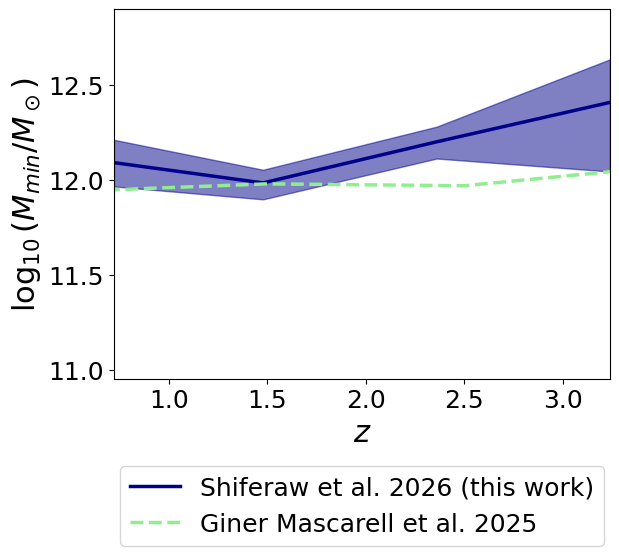

In [144]:
M_min_lo, M_min_hi = np.array(err['log10(M_min)'])[:,0], np.array(err['log10(M_min)'])[:,1]
plt.plot(zbin, M_min, color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.fill_between(zbin, M_min_lo, M_min_hi, alpha = 0.5, color = 'darkblue')
plt.plot(z_eff, M_min_array, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
# plt.plot(z_eff, M_min_giner, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.ylim(10.95,12.9)
plt.show()

In [145]:
# f_duty_giner = [0.001986832927349008, 0.001968631474455283, 0.002978657298062041, 0.001968631474455283]

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_250170/2689611749.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(f_{duty})$')


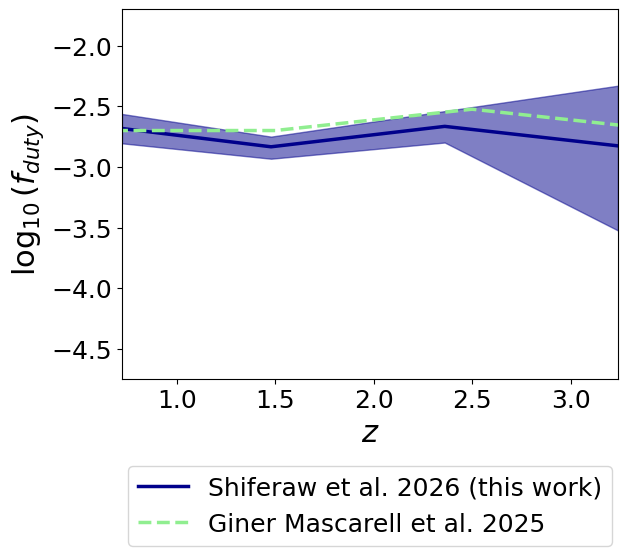

In [146]:
f_duty_lo, f_duty_hi = np.array(err['log10(f_duty)'])[:,0], np.array(err['log10(f_duty)'])[:,1]
plt.plot(zbin, f_duty, color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.fill_between(zbin, f_duty_lo, f_duty_hi, alpha = 0.5, color = 'darkblue')
# plt.fill_between(zbin, np.log10(np.array(f_duty_giner)+fduty_err_hi), np.log10(np.array(f_duty_giner)-fduty_err_lo), alpha = 0.5, color = 'lightgreen')
plt.plot(z_eff, np.log10(fduty), label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.ylim(-4.75,-1.7)
plt.show()

In [147]:
b_eff_cf20 = np.load('../results/b_eff_cf20_planck18.npy')

## Calculate 16th and 84th percentile of derived parameters

In [148]:
# for j in z_array:
# equal_weight_samples = dyfunc.resample_equal(samples, weights)
# ind = np.random.choice(range(len(equal_weight_samples)), size = 1000, replace = False)
# f_duty_samples, M_min_samples = equal_weight_samples[ind].T
cf_2h_samples, b_q_samples=[], []
for i in range(len(ind)):
    n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
    cf_2h_sample, b_q_sample = cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    cf_2h_samples.append(cf_2h_sample)
    b_q_samples.append(b_q_sample)
cf_2h_16, cf_2h_50, cf_2h_84 = np.percentile(cf_2h_samples, [16, 50, 84], axis=0)
b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])

In [149]:
n_m=np.ones(np.shape(bins))*10**f_duty[j]
cf_2h_zbin, b_q = cf_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
cf_2h_50-cf_2h_zbin

array([-4.46202806e-02, -2.23558731e-02, -1.33842875e-02, -8.78406722e-03,
       -6.10575649e-03, -4.41693170e-03, -3.29148944e-03, -2.50934474e-03,
       -1.94847619e-03, -1.53630955e-03, -1.22681127e-03, -9.90391344e-04,
       -8.06999072e-04, -6.62841027e-04, -5.48019867e-04, -4.55555358e-04,
       -3.80391457e-04, -3.18865348e-04, -2.68182705e-04, -2.26146186e-04,
       -1.91352924e-04, -1.62163077e-04, -1.37803968e-04, -1.17077546e-04,
       -9.97625770e-05, -8.46411759e-05, -7.17103483e-05, -6.02997447e-05,
       -5.01318808e-05, -4.11966512e-05, -3.34939110e-05, -2.71282857e-05,
       -2.27672952e-05, -2.14248164e-05, -2.36878791e-05, -3.02287393e-05,
       -3.92966534e-05, -4.82379460e-05, -5.38318611e-05, -5.43196493e-05,
       -4.99163165e-05, -4.21950034e-05, -3.30406001e-05, -2.39425734e-05,
       -1.57927847e-05, -8.97235942e-06, -3.52506226e-06,  6.77465311e-07,
        3.82495359e-06,  6.11747939e-06,  7.74244943e-06,  8.85750052e-06,
        9.58492067e-06,  

In [150]:
cf_2h_zbin_lo, b_q_lo = cf_2h(np.logspace(M_min_lo[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
cf_2h_zbin_hi, b_q_hi = cf_2h(np.logspace(M_min_hi[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                        recenter = False)

In [151]:
cf_2h_zbin_lo-cf_2h_16, cf_2h_zbin_hi-cf_2h_84

(array([6.83885937e-02, 3.42643905e-02, 2.05138244e-02, 1.34631606e-02,
        9.35816840e-03, 6.76974110e-03, 5.04479871e-03, 3.84602148e-03,
        2.98638970e-03, 2.35467031e-03, 1.88030860e-03, 1.51795261e-03,
        1.23687101e-03, 1.01592292e-03, 8.39938869e-04, 6.98220403e-04,
        5.83018224e-04, 4.88718414e-04, 4.11038160e-04, 3.46609645e-04,
        2.93282722e-04, 2.48544039e-04, 2.11209330e-04, 1.79442365e-04,
        1.52904066e-04, 1.29727803e-04, 1.09908988e-04, 9.24201884e-05,
        7.68361109e-05, 6.31412668e-05, 5.13354340e-05, 4.15789700e-05,
        3.48949688e-05, 3.28373790e-05, 3.63059289e-05, 4.63309720e-05,
        6.02291789e-05, 7.39333156e-05, 8.25069952e-05, 8.32546182e-05,
        7.65057198e-05, 6.46714208e-05, 5.06406536e-05, 3.66962937e-05,
        2.42052789e-05, 1.37517522e-05, 5.40279100e-06, 4.59000470e-05,
        2.59150612e-04, 4.14475232e-04, 5.24571203e-04, 6.00118831e-04,
        6.49403449e-04, 6.78830602e-04, 6.93431599e-04, 6.970338

<>:74: SyntaxWarning: invalid escape sequence '\l'
<>:74: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_250170/1037611706.py:74: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


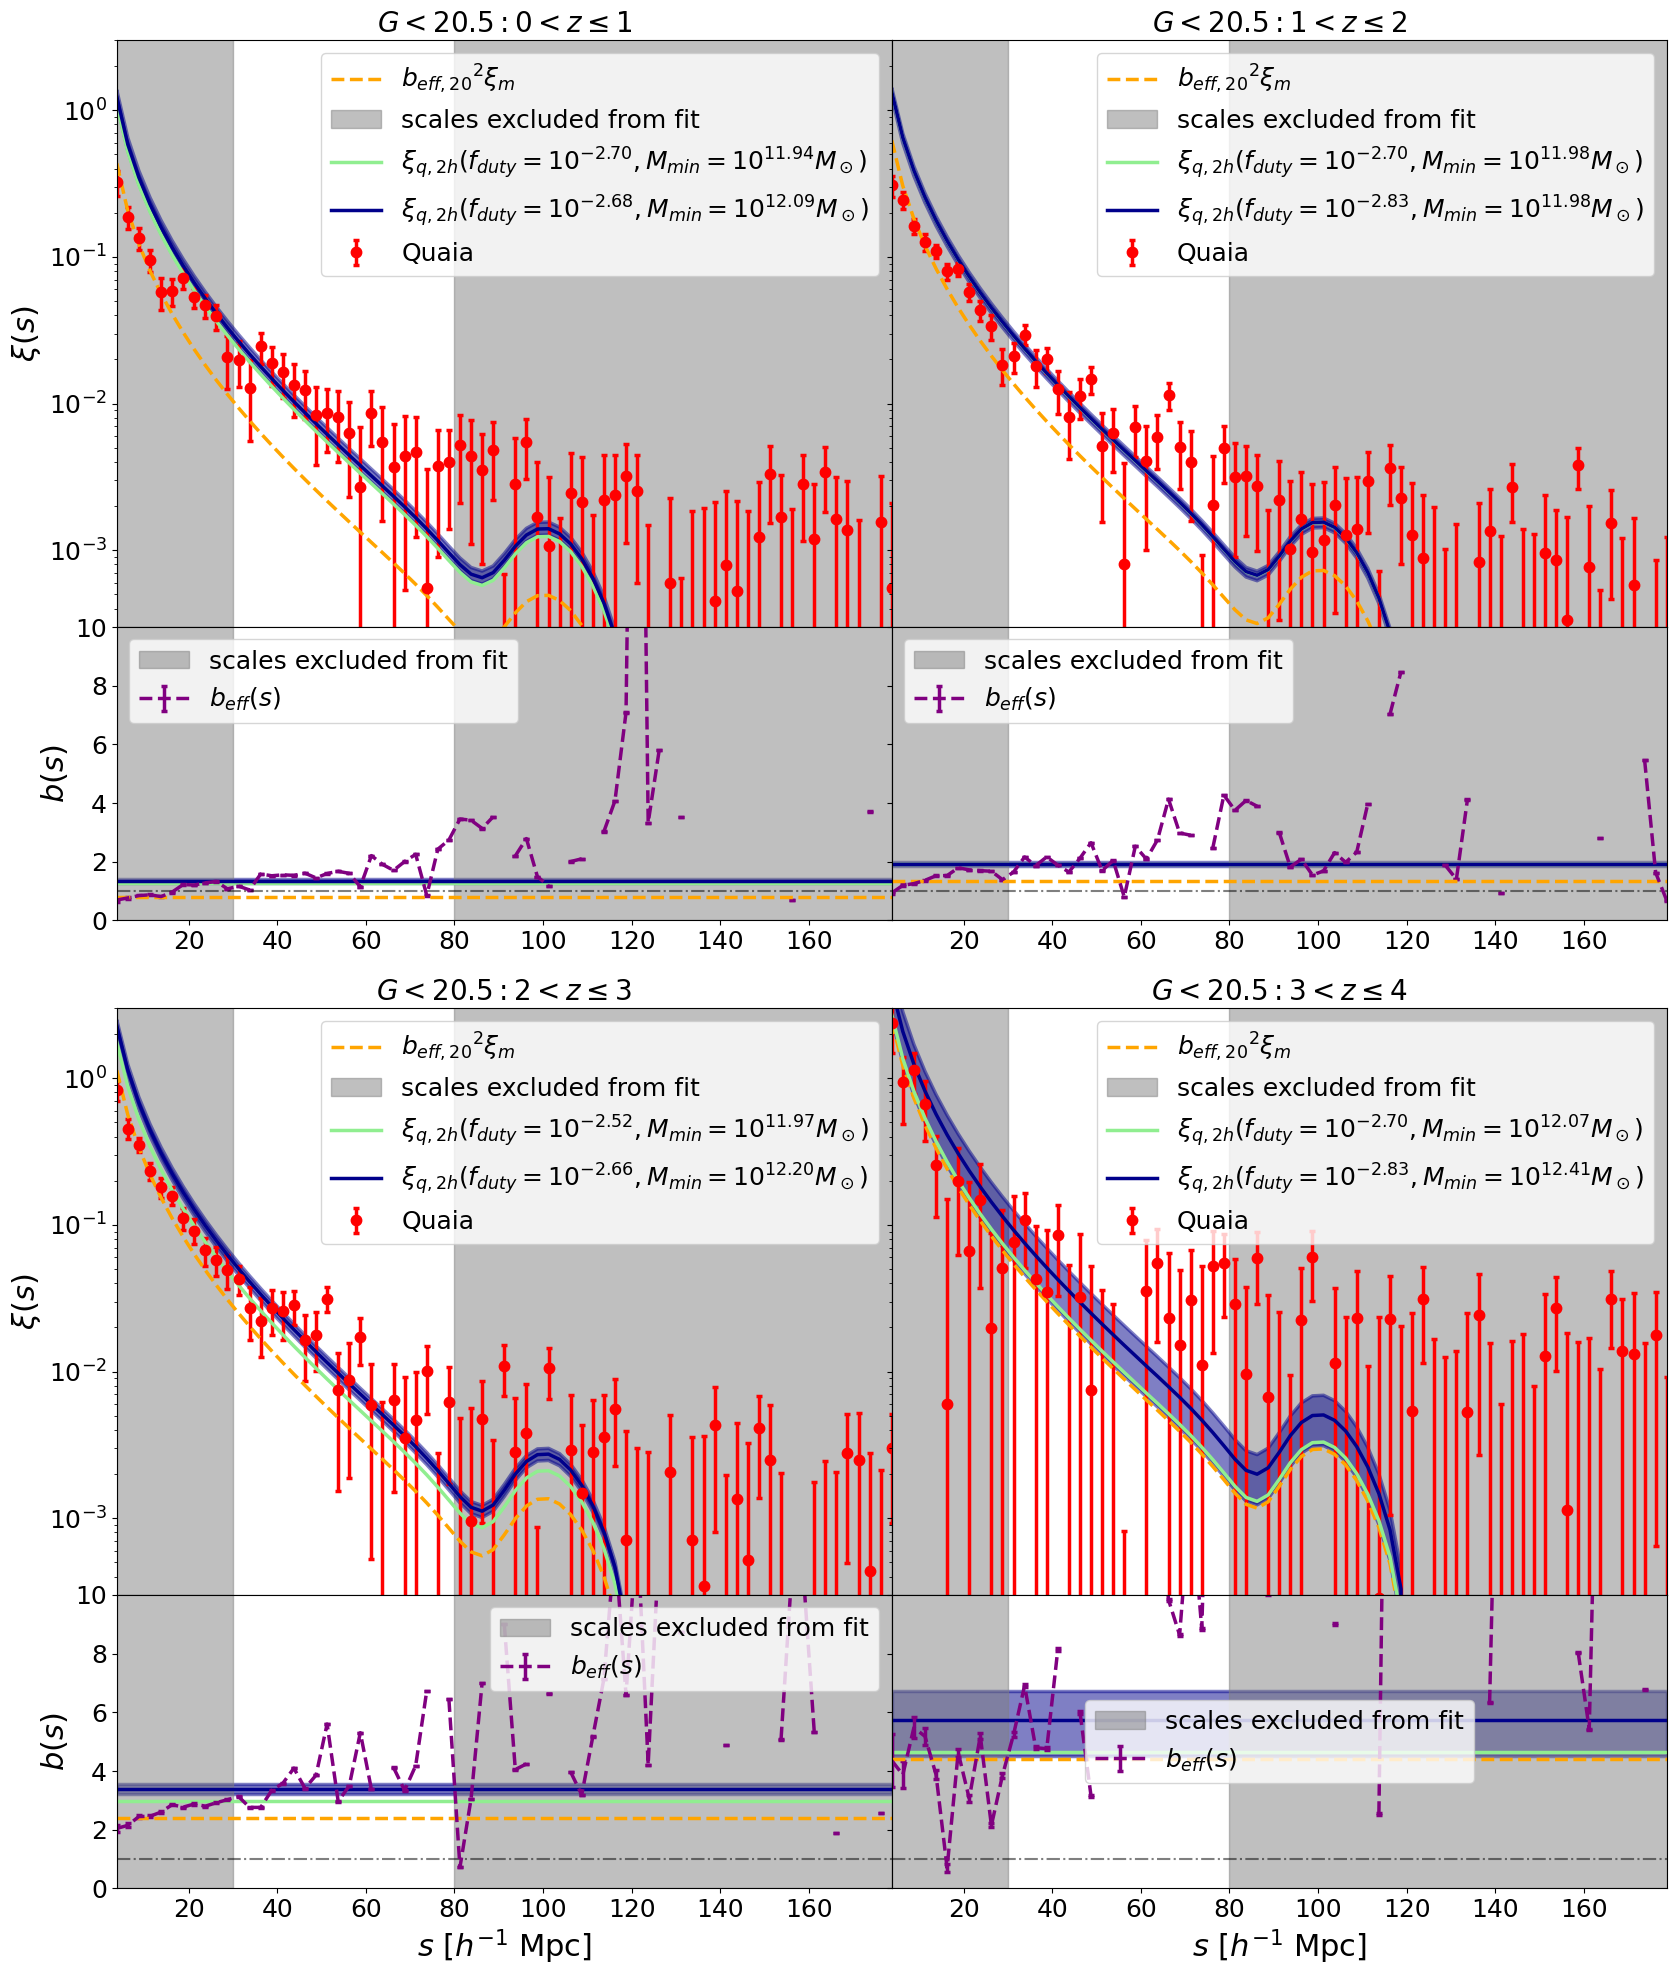

In [152]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
    
    # C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, rmin, rmax, nbins, j, cosmo)) # [np.ix_([False]+[True]*20+[False], [False]+[True]*20+[False])] # very good
    # C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    
    ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.plot(quaia.recenter(rbins_chi2), b_eff_cf20[j]**2*cf_matter_chi2[j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = '--')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)

    # old fit
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_chi2[j], recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5, 
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty[j]), M_min_array[j]),
             color = 'lightgreen')
    ax2.axhline(b_q, linewidth = 2.5, color = 'lightgreen')

    # plot new fit
    n_m=np.ones(np.shape(bins))*f_duty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')
    
    cf_2h_samples, b_q_samples=[], []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        cf_2h_sample, b_q_sample = cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)
        cf_2h_samples.append(cf_2h_sample)
        b_q_samples.append(b_q_sample)
    cf_2h_16, cf_2h_50, cf_2h_84 = np.percentile(cf_2h_samples, [16, 50, 84], axis=0)
    b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])

    ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_16, cf_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')
    ax2.axhline(b_q, linewidth = 2.5, color = 'darkblue')
    ax2.fill_between(quaia.recenter(rbins_chi2), [b_q_16]*nbins, [b_q_84]*nbins, linewidth = 2.5, color = 'darkblue', alpha = 0.5)

    # ax1.plot(quaia.recenter(rbins_chi2), cf_2h_50, linewidth = 2.5,
    #          label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]),
    #          color = 'darkblue')
    # cf_2h_zbin_lo, b_q_lo = cf_2h(np.logspace(M_min_lo[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
    #                         recenter = False)
    # cf_2h_zbin_hi, b_q_hi = cf_2h(np.logspace(M_min_hi[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
    #                         recenter = False)
    # ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_zbin_lo, cf_2h_zbin_hi, linewidth = 2.5, alpha = 0.5,
    #          color = 'darkblue')
    # ax2.axhline(b_q_50, linewidth = 2.5, color = 'darkblue')
    # ax2.fill_between(quaia.recenter(rbins_chi2), [b_q_lo]*nbins, [b_q_hi]*nbins, linewidth = 2.5, color = 'darkblue', alpha = 0.5)
    
    ax2.errorbar(quaia.recenter(rbins_chi2), b_cf_chi2[j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'purple', yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')
    ax2.axhline(b_eff_cf20[j], linewidth = 2.5, color = 'orange', linestyle = '--')
    ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)
    
    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 3)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax2.set_ylim(0, 10)
    ax2.legend()
    
    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=4

plt.show()

<>:49: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_250170/2122926617.py:49: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


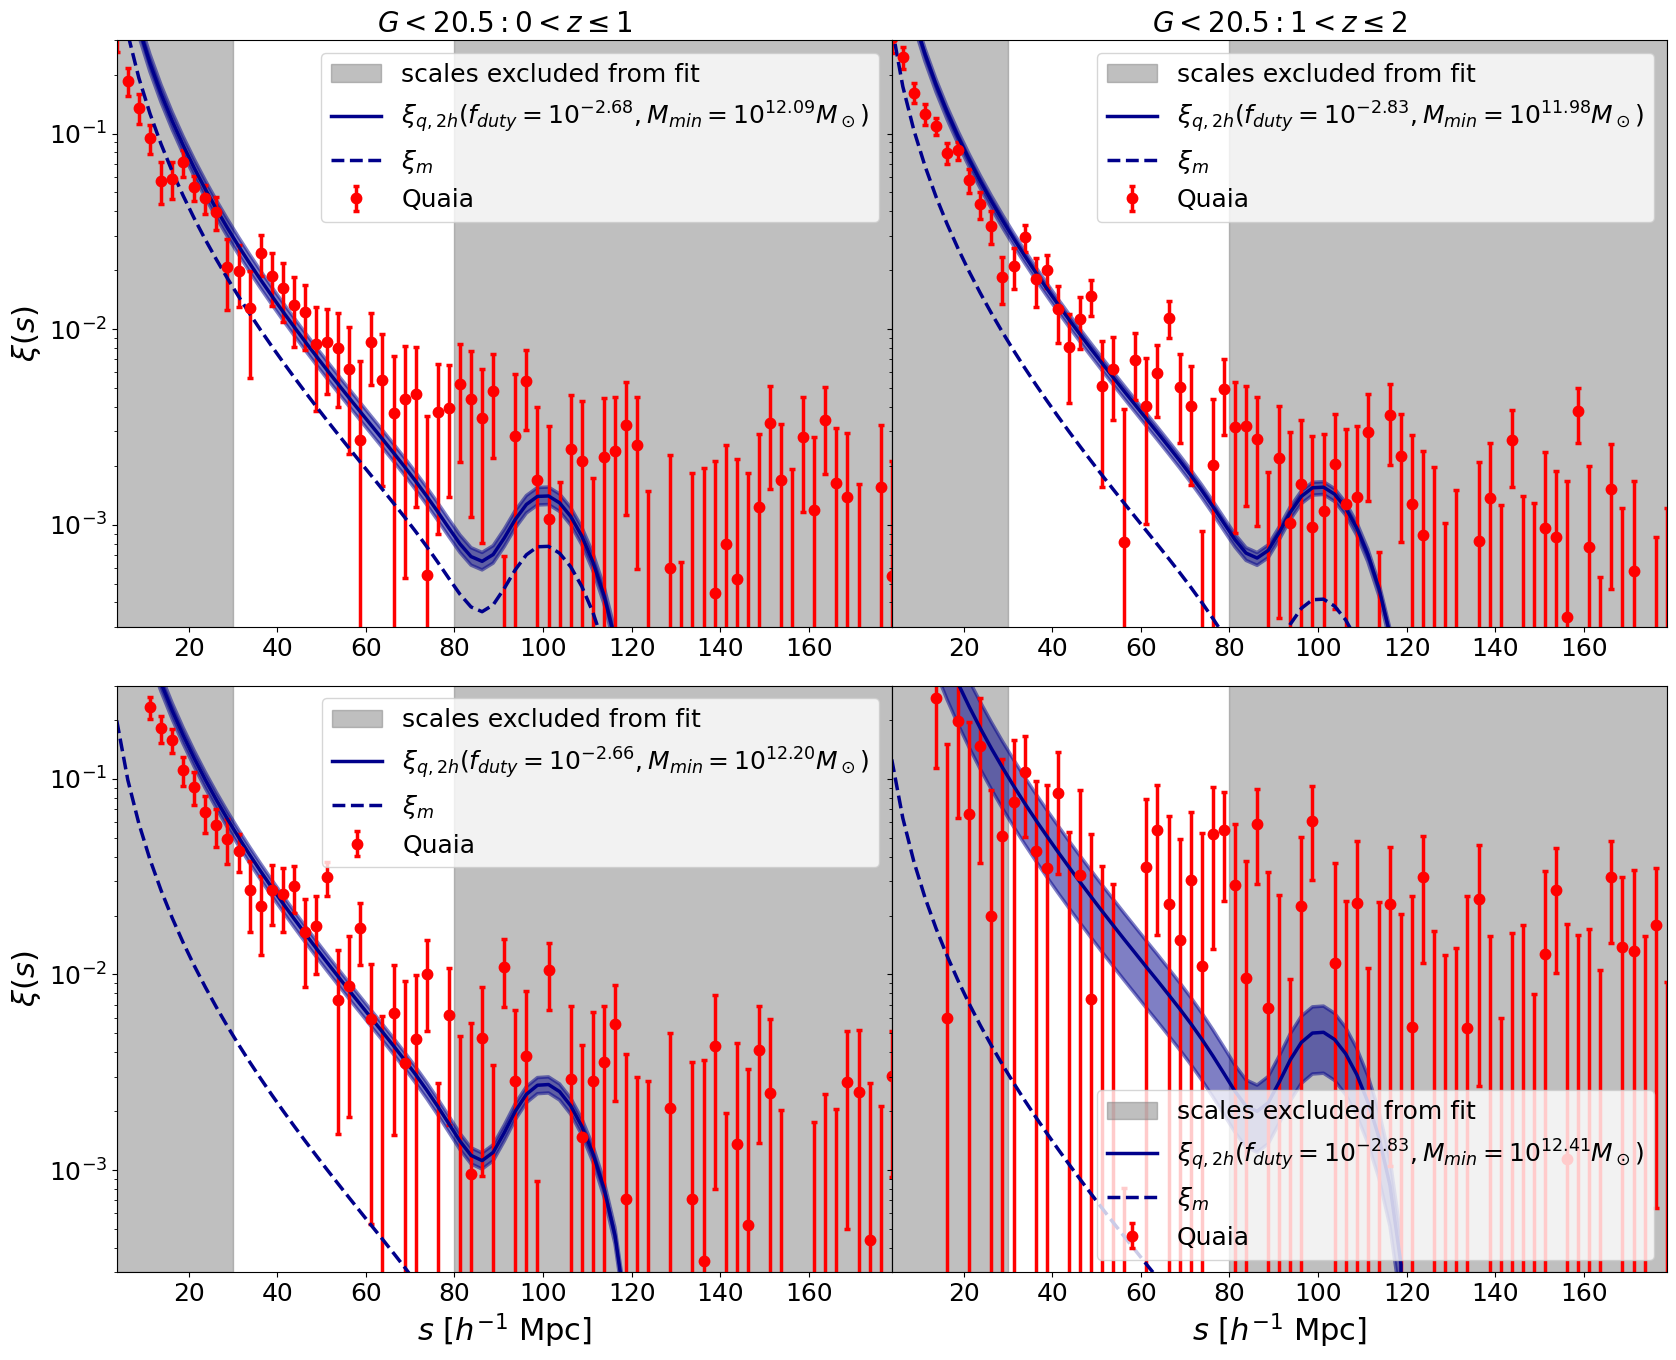

In [153]:
# remove bottom panel and just print bq somewhere
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.1, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j])
    
    # C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, rmin, rmax, nbins, j, cosmo)) # [np.ix_([False]+[True]*20+[False], [False]+[True]*20+[False])] # very good
    # C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
           
    ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)

    # plot new fit
    n_m=np.ones(np.shape(bins))*f_duty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')
    ax1.plot(quaia.recenter(rbins_chi2), cf_matter_chi2[j], linewidth = 2.5,
             label = r'$\xi_{{m}}$', linestyle = '--', 
             color = 'darkblue')

    cf_2h_samples = []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*f_duty_samples[j][i]
        cf_2h_sample, _ = cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)
        cf_2h_samples.append(cf_2h_sample)
    cf_2h_16, cf_2h_50, cf_2h_84 = np.percentile(cf_2h_samples, [16, 50, 84], axis=0)
    ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_16, cf_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')    
    # cf_2h_zbin_lo, b_q_lo = cf_2h(np.logspace(M_min_lo[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
    #                         recenter = False)
    # cf_2h_zbin_hi, b_q_hi = cf_2h(np.logspace(M_min_hi[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
    #                         recenter = False)
    # ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_zbin_lo, cf_2h_zbin_hi, linewidth = 2.5, alpha = 0.5,
    #          color = 'darkblue')

    if j % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_ylim(3e-4, 3e-1)
    ax1.legend()
    
    if j % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        # ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        # ax2.set_yticklabels([])

    if j > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=2

plt.show()

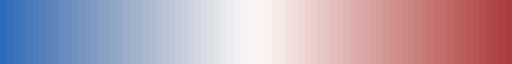

In [154]:
cmap_M_min = sns.color_palette("vlag", n_colors = len(bins))
palette_M_min = matplotlib.colors.ListedColormap(cmap_M_min)
palette_M_min

<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:63: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:63: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_250170/702562715.py:44: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
/tmp/ipykernel_250170/702562715.py:63: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


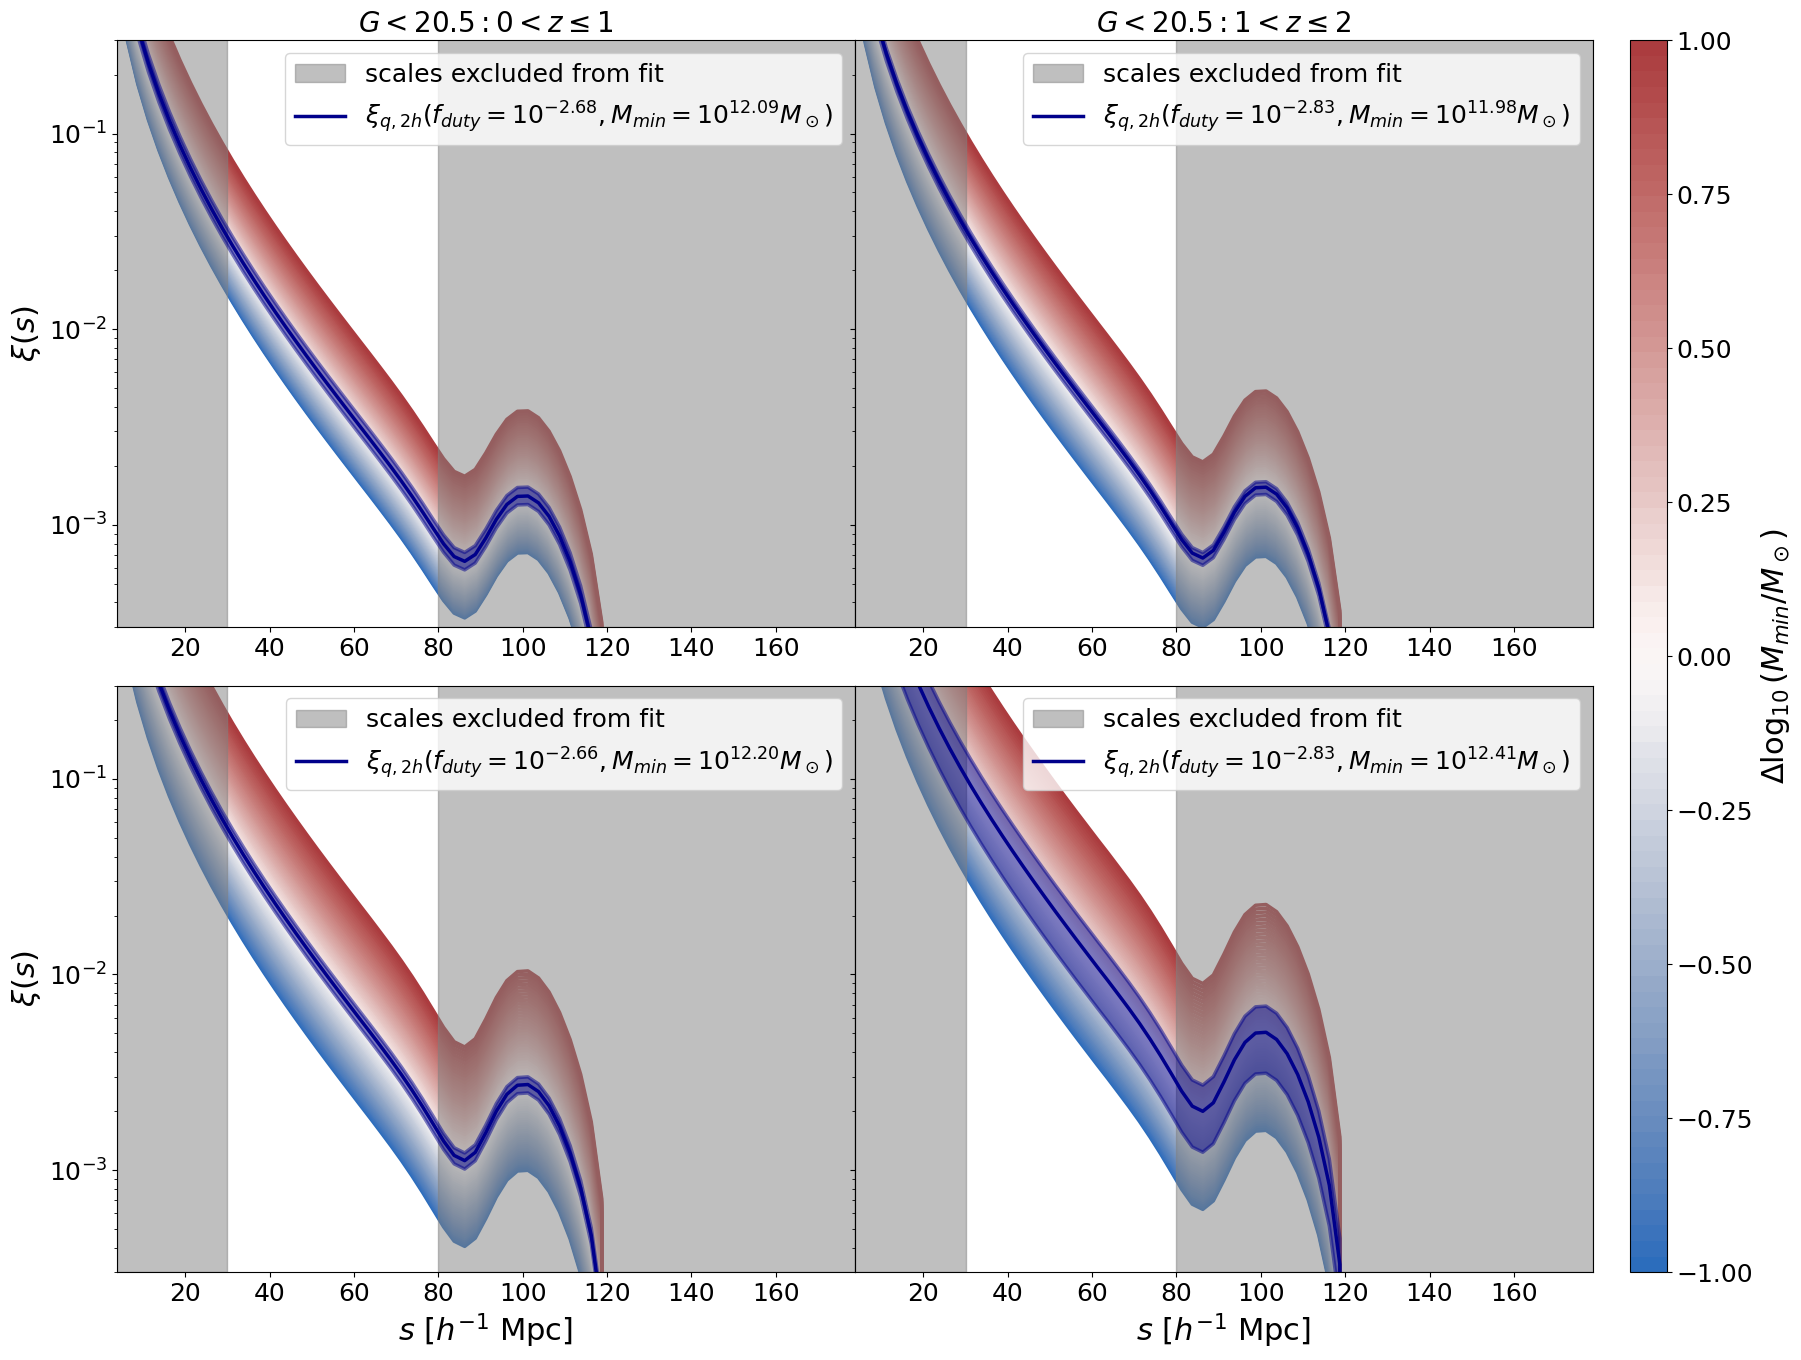

In [155]:
# remove bottom panel and just print bq somewhere
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 4, hspace = 0.1, wspace = 0, width_ratios = [1,1,0.05,0.05])

l = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+l])
    
    # C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
           
    # ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
    #             yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)

    # plot new fit
    n_m=np.ones(np.shape(bins))*f_duty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')

    for k in range(len(bins)):
        cf_2h_sample, _ = cf_2h(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), n_m, a_zbin[j], 
                 cosmo_planck18, cf_matter_chi2[j], recenter = False)
        ax1.plot(quaia.recenter(rbins_chi2), cf_2h_sample, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
        
    cf_2h_samples = []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*f_duty_samples[j][i]
        cf_2h_sample, _ = cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)
        cf_2h_samples.append(cf_2h_sample)
    cf_2h_16, cf_2h_50, cf_2h_84 = np.percentile(cf_2h_samples, [16, 50, 84], axis=0)
    ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_16, cf_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')    
    
    if j % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_ylim(3e-4, 3e-1)
    ax1.legend()
    
    if j % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')

    else:
        ax1.set_yticklabels([])

    if j > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j == 1:
        l+=2

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [156]:
b_q_percentile = []
for j in z_array:
    b_q_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        b_q_samples.append(cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)[1])
    b_q_percentile.append(np.percentile(b_q_samples, [16, 84]))
b_q_lo, b_q_hi = np.array(b_q_percentile).T

<>:56: SyntaxWarning: invalid escape sequence '\D'
<>:56: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_250170/2217826274.py:56: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


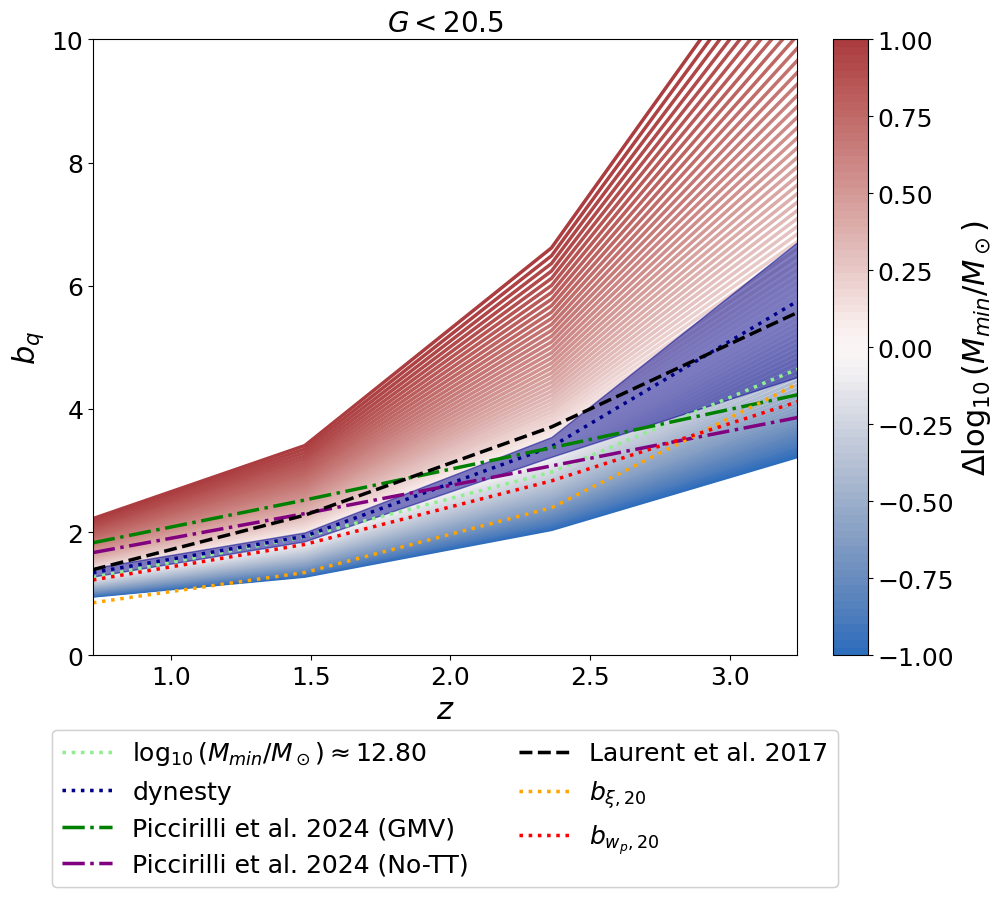

In [157]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
b_q = [cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
             recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

b_q = [cf_2h(np.logspace(M_min[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a_zbin[j], cosmo_planck18, 
             cf_matter_chi2[j], recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

# b_q_lo = [cf_2h(np.logspace(M_min_lo[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a_zbin[j], cosmo_planck18, 
#              cf_chi2[j], recenter = False)[1] for j in z_array]
# b_q_hi = [cf_2h(np.logspace(M_min_hi[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a_zbin[j], cosmo_planck18, 
#              cf_chi2[j], recenter = False)[1] for j in z_array]
ax1.fill_between(zbin, b_q_lo, b_q_hi, alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

for k in range(len(bins)):
    b_q = [cf_2h(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*f_duty[j], a_zbin[j], 
                 cosmo_planck18, cf_matter_chi2[j], recenter = False)[1] for j in z_array]
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, b_quaia(1.26, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_quaia(1.15, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(zbin[0], zbin[-1])
ax1.set_ylabel(r'$b_q$')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [158]:
M_h_percentile = []
for j in z_array:
    M_h_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        M_h_samples.append(M(np.logspace(M_min_samples[j][i], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0])
    M_h_percentile.append(np.percentile(M_h_samples, [16, 84]))
M_h_lo, M_h_hi = np.array(M_h_percentile).T

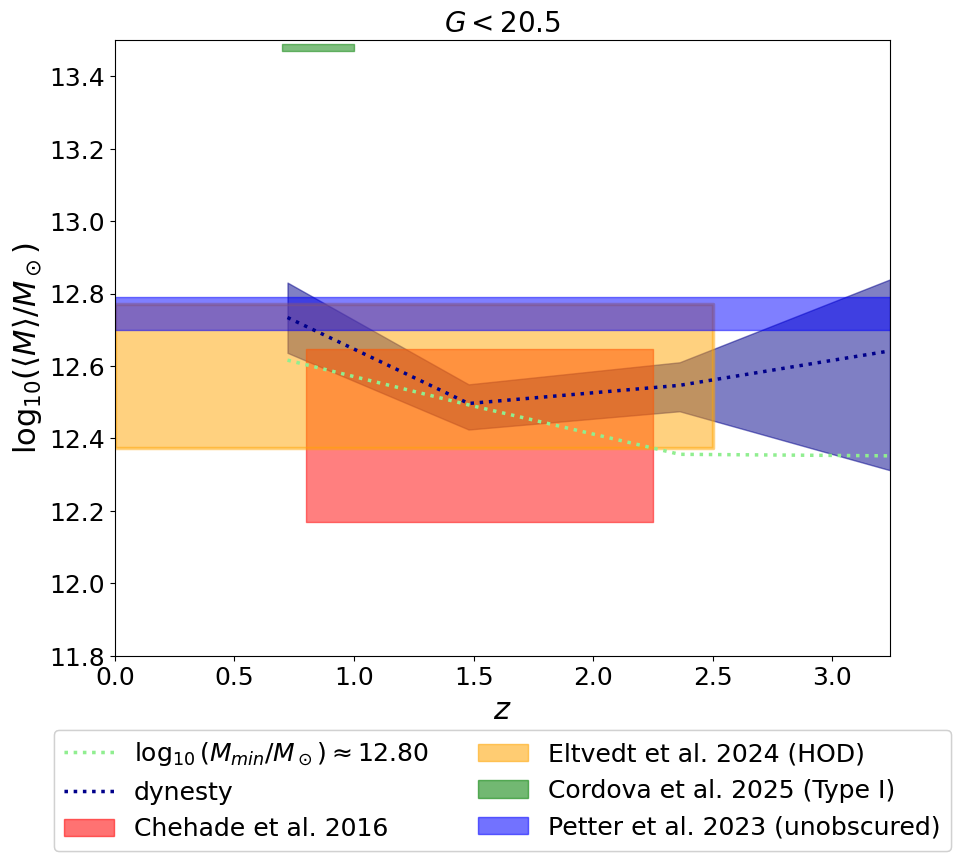

In [159]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
# plt.fill_between(zbin, [11.94]*len(zbin), [12.07]*len(zbin), alpha = 0.5, label = 'Giner Mascarell et al. 2025', color = 'lightgreen')

M_h = [M(np.logspace(M_min[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

# M_h_lo = [M(np.logspace(M_min_lo[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, 
#          recenter = False)[0] for j in z_array]
# M_h_hi = [M(np.logspace(M_min_hi[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, 
#          recenter = False)[0] for j in z_array]
ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), 
                # mpatches.Patch(color='lightgreen', alpha = 0.5), 
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [#'Giner Mascarell et al. 2025', 
                                          r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(11.8, 13.5)

plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\D'
<>:46: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_250170/1482196861.py:46: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


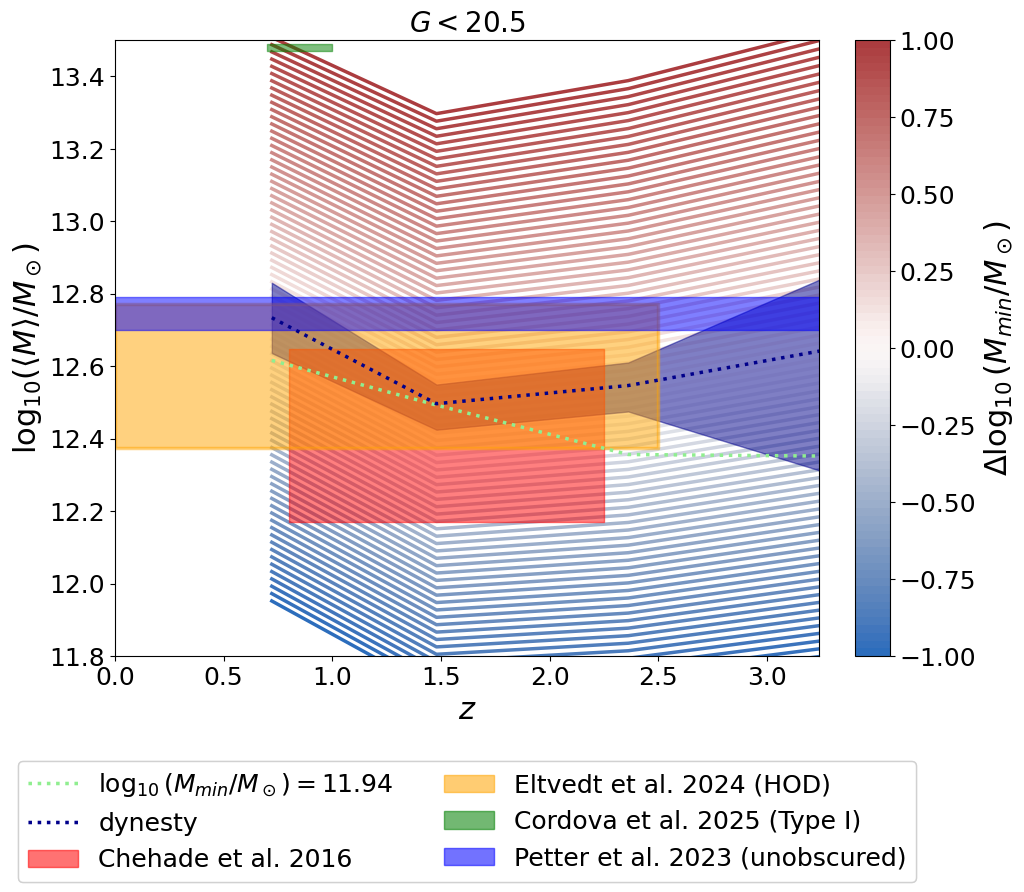

In [160]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    M_h = [M(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
             color = cmap_M_min[k], zorder = 0) #, alpha = (1+k)/len(bins))
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

M_h = [M(np.logspace(M_min[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0] for j in range(len(z_array))]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 'dynesty',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.15), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(11.8, 13.5)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [161]:
fduty_array = np.logspace(-5,0, 51) #-4

In [162]:
cmap_fduty_k = sns.color_palette("vlag", n_colors = len(fduty_array))

In [163]:
n_q_percentile = []
for j in z_array:
    n_q_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        n_q_samples.append(M(np.logspace(M_min_samples[j][i], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[1])
    n_q_percentile.append(np.percentile(n_q_samples, [16, 84]))
n_q_theory_fit_lo, n_q_theory_fit_hi = np.array(n_q_percentile).T

<>:46: SyntaxWarning: invalid escape sequence '\D'
<>:86: SyntaxWarning: invalid escape sequence '\D'
<>:46: SyntaxWarning: invalid escape sequence '\D'
<>:86: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_250170/4256676480.py:46: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
/tmp/ipykernel_250170/4256676480.py:86: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(f_{duty})$')


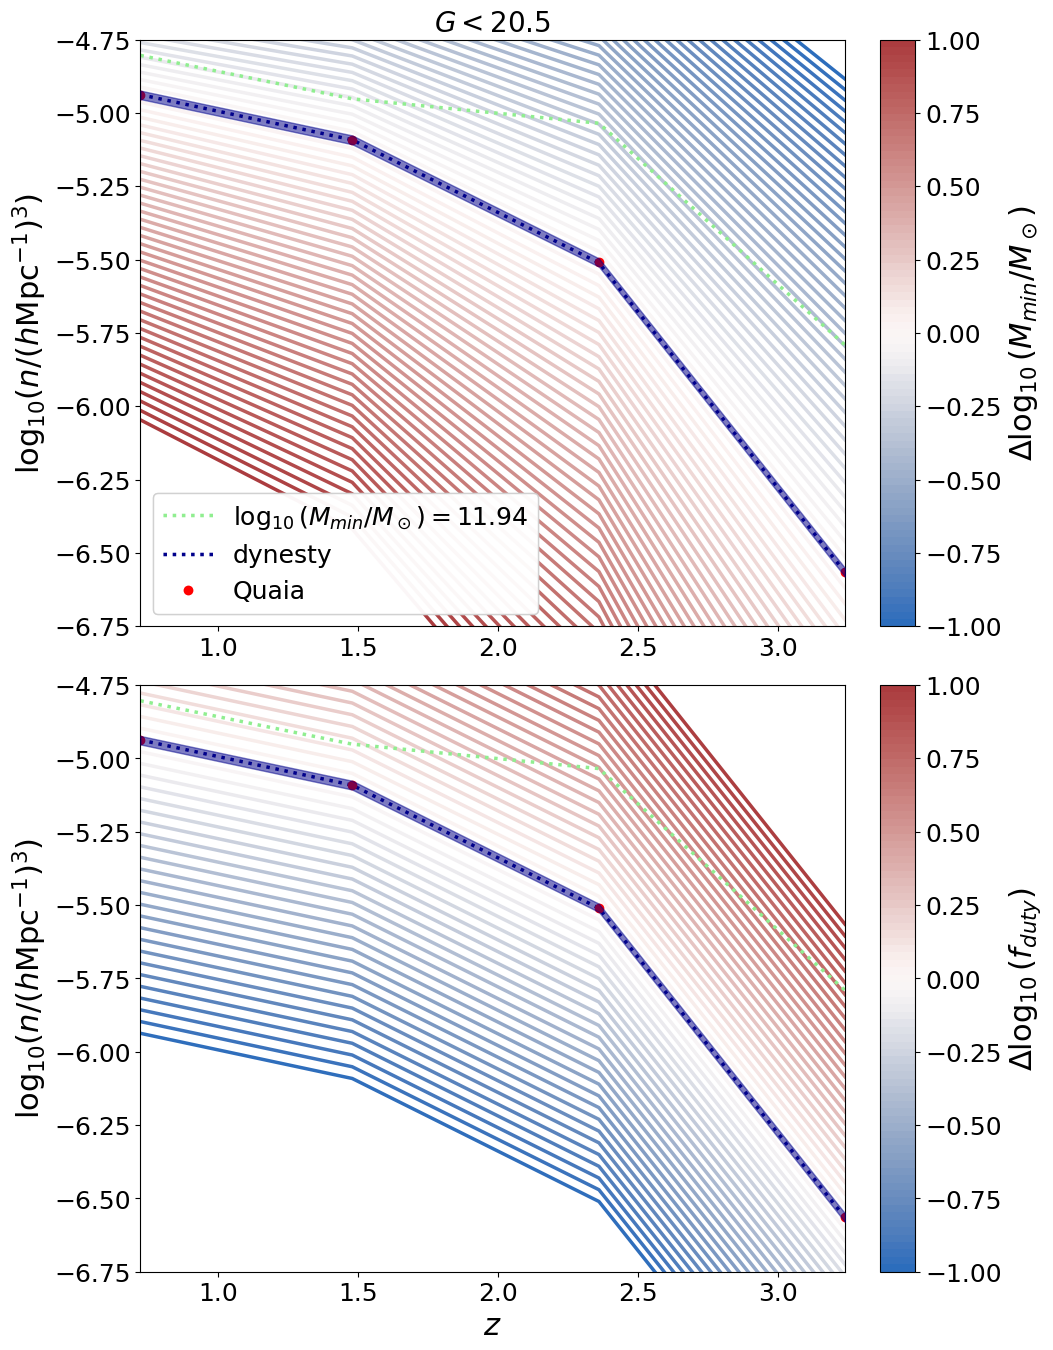

In [164]:
fig = plt.figure(figsize = (10, 16))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(2, 3, width_ratios = [1, 0.05, 0.05], wspace = 0, hspace = 0.1)
ax1 = fig.add_subplot(gs[0])
ylim = -6.75, -4.75

for k in range(len(bins)):
    
    n_q_theory = [M(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(f_duty[0]*100, f_duty[-1]*100, np.log10(bins[0]), 
                                                                                                  np.log10(bins[-1])), color = cmap_M_min[k])
    
n_q_theory, n_q_theory_fit = [], [] #, n_q_theory_fit_lo, n_q_theory_fit_hi = [], [], [], []
for j in z_array:
    
    n_q_theory.append(M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
    
    n_m=np.ones(np.shape(bins))*10**f_duty[j]
    n_q_theory_fit.append(M(np.logspace(M_min[j], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
    # n_q_theory_fit_lo.append(M(np.logspace(M_min_lo[j], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
    # n_q_theory_fit_hi.append(M(np.logspace(M_min_hi[j], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])

ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, label = r'$\chi^2$ minimization', zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_xlim(zbin[0], zbin[-1])

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5, 
                       label = 'dynesty'), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

# ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[0,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
# plt.show()

# fig = plt.figure(figsize = (10, 8))
# labels_cf = ['qq', r'$\xi_{2h}$']
# gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[3])
i = 1
l = 38

for k in range(len(fduty_array)):

    n_q_theory=[]
    for j in z_array:
        
        n_m = np.ones(np.shape(bins))*10**(f_duty[j]-1+k/int(len(fduty_array)/2))
        n_q_theory.append(M(np.logspace(M_min[j], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
        
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap_fduty_k[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins)) np.log10(bins[l])

ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'dynesty') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

# ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)
# ax1.legend()
ax1.set_xlim(zbin[0], zbin[-1])

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[1,-1]), 
                    label = '$\Delta \log_{10}(f_{duty})$')
plt.show()

# Debug covariance
## Check that masking is the same

In [393]:
# Create the bins array
offset = 2.5
delta_max = 1 #64
delta_min = 1 #np.min((np.floor((30-0.15)/offset), delta_max))

rmin = 30-delta_min*offset # 0.1 # start higher # 1.4 # 30
rmax = 80+delta_max*offset # 200
nbins = 20 + int(delta_min+delta_max) #90 #20
rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
rbins, quaia.recenter(rbins), np.diff(quaia.recenter(rbins))

(array([27.5, 30. , 32.5, 35. , 37.5, 40. , 42.5, 45. , 47.5, 50. , 52.5,
        55. , 57.5, 60. , 62.5, 65. , 67.5, 70. , 72.5, 75. , 77.5, 80. ,
        82.5]),
 array([28.75, 31.25, 33.75, 36.25, 38.75, 41.25, 43.75, 46.25, 48.75,
        51.25, 53.75, 56.25, 58.75, 61.25, 63.75, 66.25, 68.75, 71.25,
        73.75, 76.25, 78.75, 81.25]),
 array([2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5,
        2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5]))

In [178]:
j = 0
C_unmasked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, rmin, rmax, nbins, j, cosmo))
C_masked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, 30, 80, 20, j, cosmo))

In [179]:
r = quaia.recenter(rbins) 
rpmask = (r >= 30) & (r  <= 80)
ix_grid = np.ix_(rpmask, rpmask)

In [180]:
np.max(C_unmasked[ix_grid]-C_masked)

1.2705494208814505e-21

(-1.0, 1.0)


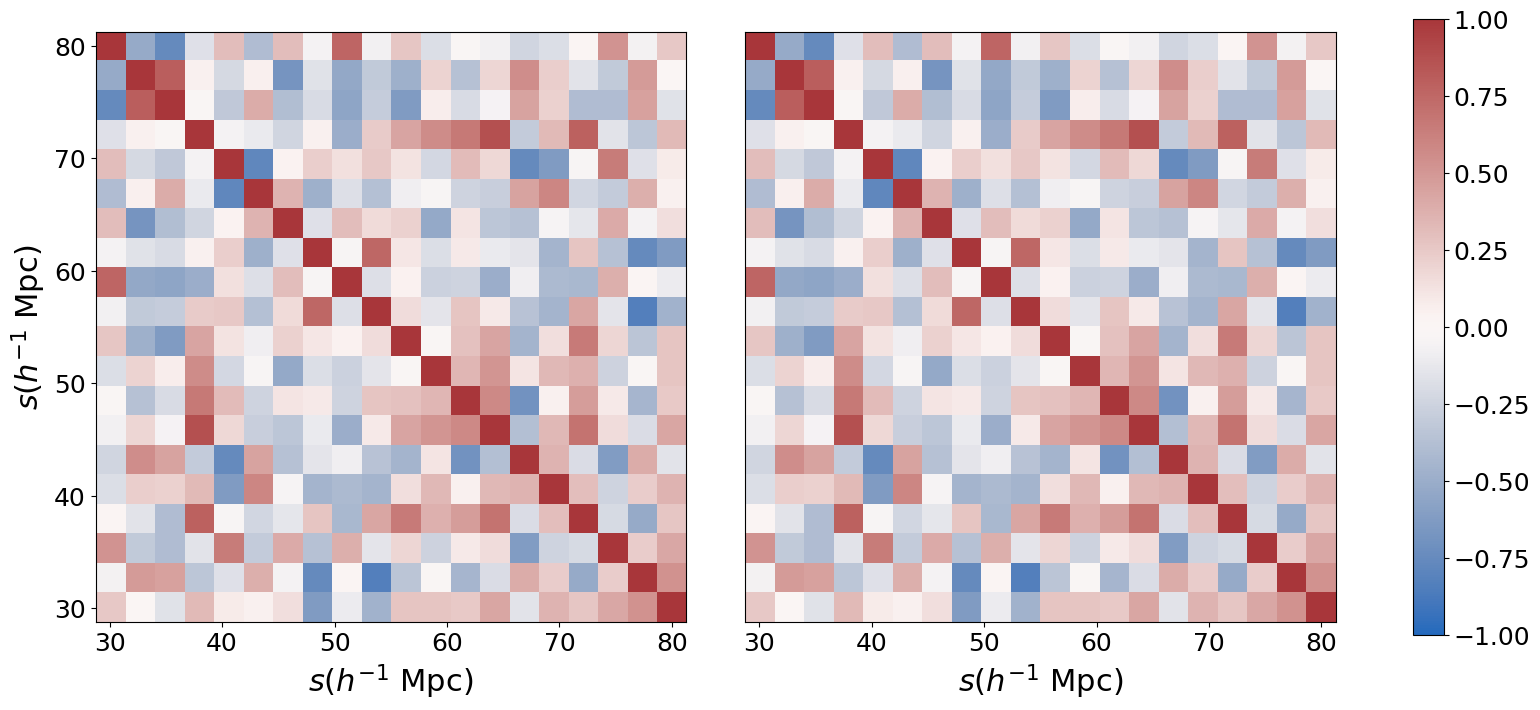

In [181]:
cmap = sns.color_palette("vlag", as_cmap=True)

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0.1, hspace = 0.1)
# axes = []
# for i in range(len(zbin_array)-1):
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_N{}_{}.npy'.format(G_hi, rmin, rmax, nbins, zbin_array[i], zbin_array[i+1], N, cosmo))
matrix = np.corrcoef(C_unmasked[ix_grid])
image = ax1.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
matrix = np.corrcoef(C_masked)
image = ax2.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
print(image.get_clim())
# if i>1:
ax1.set_xlabel('$s (h^{-1}$ Mpc)')
ax2.set_xlabel('$s (h^{-1}$ Mpc)')
# else:
#     ax1.set_xticks([])
# if i %2 == 0:
ax1.set_ylabel('$s (h^{-1}$ Mpc)')
# else:
ax2.set_yticks([])
# ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]))
# axes.append(ax1)
    
fig.colorbar(image, ax = [ax1, ax2])
plt.show()

## Check the $z_\mathrm{max}$ limit

In [78]:
C_unmasked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{:.1f}_N25_{}.npy'.format(G_hi, 30, 80, 20, z_bins[j], z_bins[j+1], 'cosmo_planck18'))
C_masked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, 30, 80, 20, j, cosmo))

In [79]:
np.max(C_unmasked-C_masked)

0.0

(-1.0, 1.0)


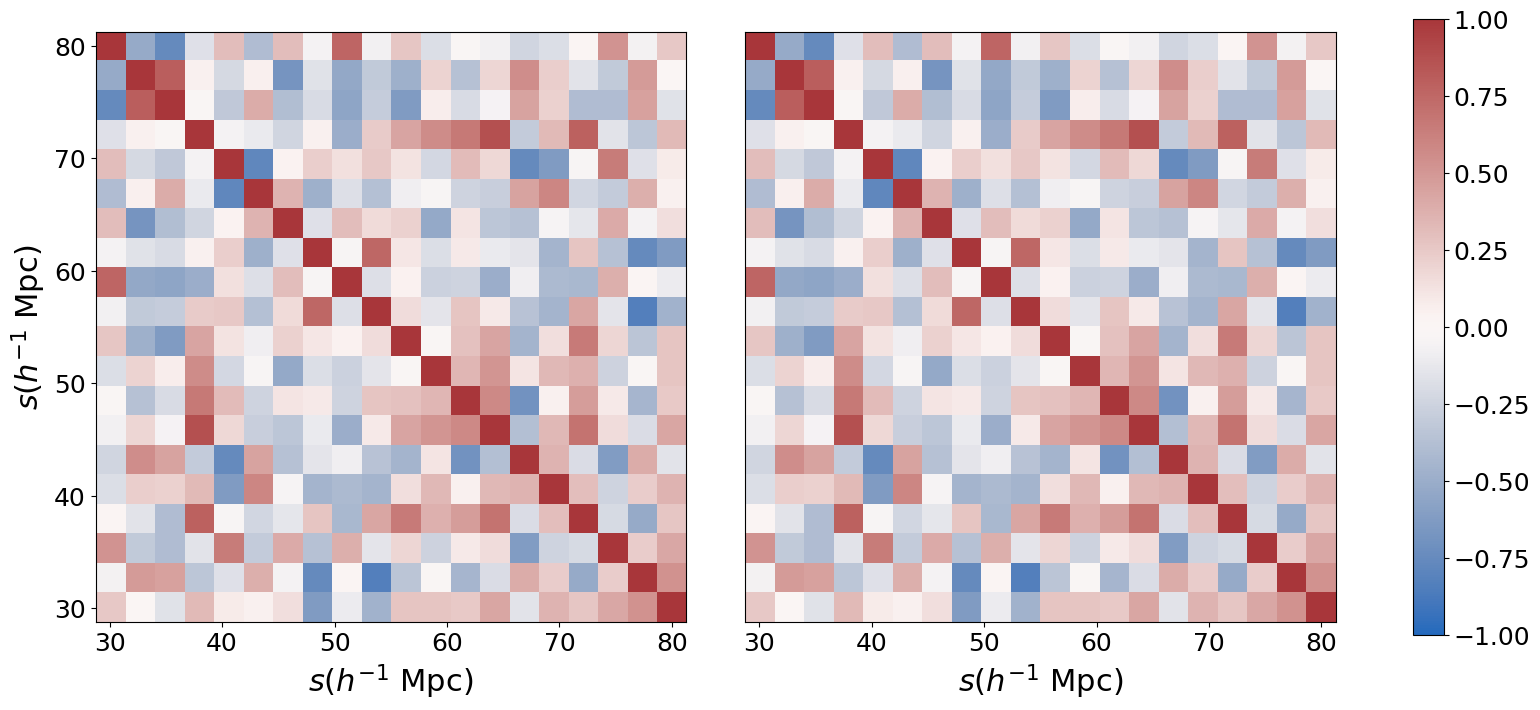

In [80]:
cmap = sns.color_palette("vlag", as_cmap=True)

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0.1, hspace = 0.1)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

matrix = np.corrcoef(C_unmasked)
image = ax1.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
matrix = np.corrcoef(C_masked)
image = ax2.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
print(image.get_clim())
ax1.set_xlabel('$s (h^{-1}$ Mpc)')
ax2.set_xlabel('$s (h^{-1}$ Mpc)')
ax1.set_ylabel('$s (h^{-1}$ Mpc)')
ax2.set_yticks([])
    
fig.colorbar(image, ax = [ax1, ax2])
plt.show()

## Check the cosmology

In [81]:
C_unmasked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, 30, 80, 20, j))
C_masked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, 30, 80, 20, j, cosmo))

In [82]:
np.max(C_unmasked-C_masked)

9.563796525941806e-06

(-1.0, 1.0)


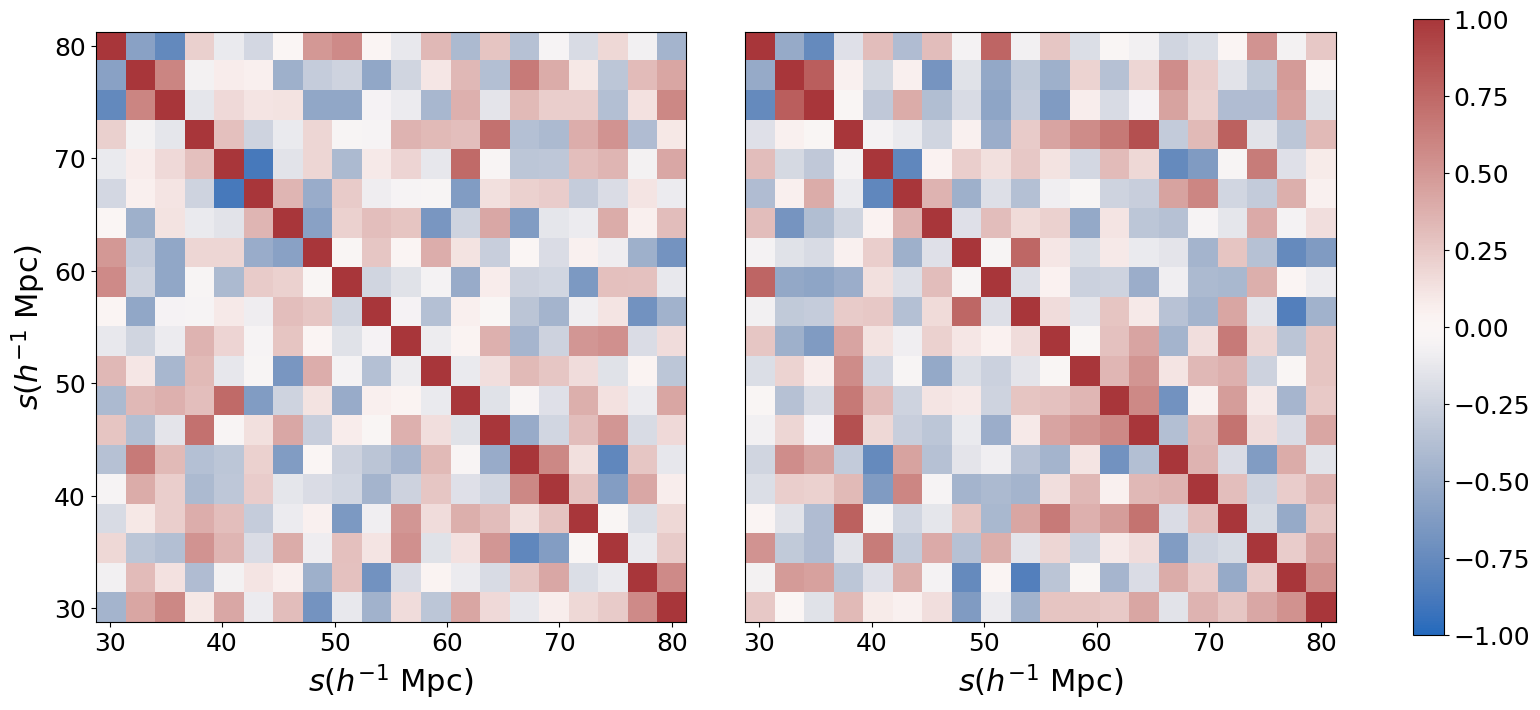

In [83]:
cmap = sns.color_palette("vlag", as_cmap=True)

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0.1, hspace = 0.1)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

matrix = np.corrcoef(C_unmasked)
image = ax1.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
matrix = np.corrcoef(C_masked)
image = ax2.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
print(image.get_clim())
ax1.set_xlabel('$s (h^{-1}$ Mpc)')
ax2.set_xlabel('$s (h^{-1}$ Mpc)')
ax1.set_ylabel('$s (h^{-1}$ Mpc)')
ax2.set_yticks([])
    
fig.colorbar(image, ax = [ax1, ax2])
plt.show()

### Check the number of bins

In [172]:
C_unmasked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N25_{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], cosmo))
C_masked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, 30, 80, 20, j, cosmo))

In [173]:
r = quaia.recenter(rbins_chi2) 
rpmask = (r >= 30) & (r  <= 80)
ix_grid = np.ix_(rpmask, rpmask)

In [174]:
np.max(C_unmasked[ix_grid]-C_masked)

7.551764857589067e-06

(-1.0, 1.0)


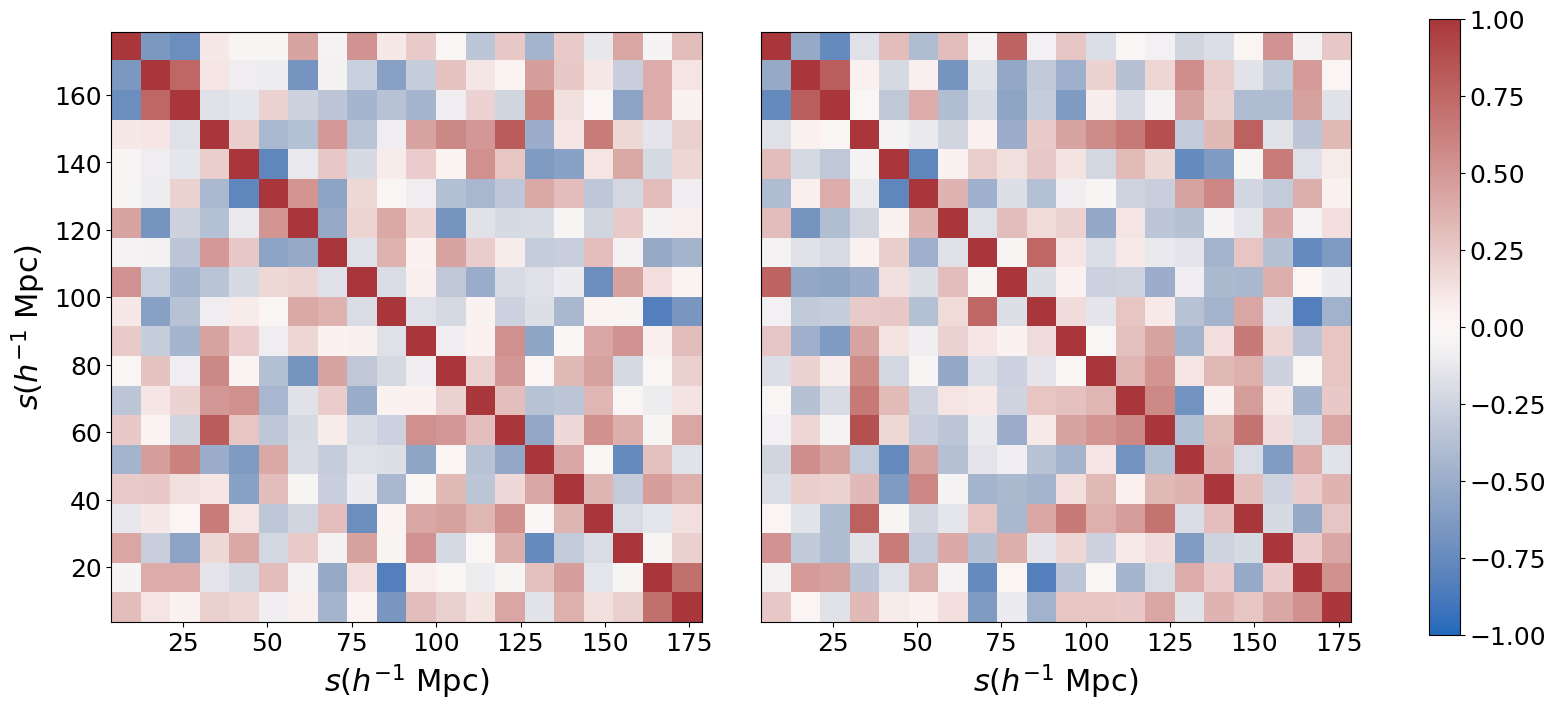

In [176]:
cmap = sns.color_palette("vlag", as_cmap=True)

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0.1, hspace = 0.1)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

matrix = np.corrcoef(C_unmasked[ix_grid])
image = ax1.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
matrix = np.corrcoef(C_masked)
image = ax2.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
print(image.get_clim())
ax1.set_xlabel('$s (h^{-1}$ Mpc)')
ax2.set_xlabel('$s (h^{-1}$ Mpc)')
ax1.set_ylabel('$s (h^{-1}$ Mpc)')
ax2.set_yticks([])
    
fig.colorbar(image, ax = [ax1, ax2])
plt.show()